In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import (
    classification_report,
    f1_score,
    precision_recall_fscore_support,
    accuracy_score,           # subset accuracy = exact set match
    jaccard_score,
    multilabel_confusion_matrix,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import re
from math import isclose
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

import json
import numpy as np
from pathlib import Path
import os

from tqdm import tqdm
import difflib
from sklearn.metrics import precision_score, recall_score, f1_score
from difflib import SequenceMatcher

tqdm.pandas()

In [6]:
import ast


In [120]:
ms_hermes = pd.read_csv("./data/ms_berger_sr/HERMES_INCLUDED_PMIDs_valid_title_annotated.csv")
ms_hermes = ms_hermes.rename(columns={'pmid':'PMID'})
ms_hermes = ms_hermes.drop(columns={'doi'})
ms_hermes = ms_hermes.fillna("not-reported")

def merge_tested_drugs(row):
    drugs = [
        str(row["Tested drug(s)"]).strip(),
        str(row["Tested drug 2"]).strip(),
        str(row["Tested drug 3"]).strip(),
    ]
    # Keep only valid entries (not 'not-reported', not empty, not NaN)
    valid = [d for d in drugs if d and d.lower() != "not-reported" and d.lower() != "nan"]
    return "|".join(valid) if valid else "not-reported"

ms_hermes["Tested drug(s)"] = ms_hermes.apply(merge_tested_drugs, axis=1)
ms_hermes = ms_hermes.drop(columns=["Tested drug 2", "Tested drug 3"])
ms_hermes["DOI"] = ms_hermes["DOI"].str.strip().str.lower()

ms_hermes.shape

(464, 12)

In [121]:
ms_hermes.head()

,PMID,title,DOI,Animal model,Species,Strain,Sex,Age,Tested drug(s),Comparator,Outcome,Total number of animals
0,27633171,Enterococcus faecium strain L-3 and glatiramer...,10.3920/bm2016.0018,EAE,rat,Wistar,female,12,Glatiramer acetate,control,1.0,122.0
1,24063549,Synergistic effects of atorvastatin and all-tr...,10.3109/08820139.2013.825269,EAE,mouse,C57BL/6,female,7,Atorvastatin,control,1.0,not-reported
2,30185466,Reduced Microglial Activity and Enhanced Gluta...,10.1523/jneurosci.0398-18.2018,EAE,mouse,C57BL/6,female,9,Minocycline,control,not-reported,not-reported
3,35496821,Loss of thymic function promotes EAE relapse i...,10.1016/j.crimmu.2022.03.001,EAE,mouse,C57BL/6 Foxp3-GFP,both,9,Alemtuzumab,control,1.0,not-reported
4,23954214,Efficacy of vitamin D in treating multiple scl...,10.1016/j.expneurol.2013.08.002,EAE,rat,Dark Agouti,female,3,Vitamin D3,control,1.0,163.0


In [122]:
ms_hermes_rob = pd.read_excel("./data/ms_berger_sr/mined_rob_with_addpaper.xlsx", index_col=0)[['doi','Randomization','Blinding', 'Welfare','Samplesize']]
ms_hermes_rob = ms_hermes_rob.dropna(subset=["doi"])
ms_hermes_rob["doi"] = ms_hermes_rob["doi"].str.strip().str.lower()

ms_hermes_rob

,doi,Randomization,Blinding,Welfare,Samplesize
File.title,,,,,
10.1002_acn3.251.pdf,10.1002/acn3.251,not reported,not reported,not reported,not reported
10.1002_acn3.94.pdf,10.1002/acn3.94,not reported,not reported,yes,not reported
10.1002_ana.10353.pdf,10.1002/ana.10353,not reported,not reported,not reported,not reported
10.1002_ana.21581.pdf,10.1002/ana.21581,not reported,not reported,not reported,not reported
10.1002_ana.24217.pdf,10.1002/ana.24217,not reported,yes,yes,not reported
...,...,...,...,...,...
Additional_papers/10.1038s43856-023-00300-1.pdf,10.1038/s43856-023-00300-1,yes,yes,yes,yes
Additional_papers/10.1073pnas.2306816121.pdf,10.1073/pnas.2306816121,not reported,not reported,not reported,not reported
Additional_papers/10.1096fj.202301557RR.pdf,10.1096/fj.202301557rr,yes,yes,yes,yes


In [123]:
ms_hermes = ms_hermes.merge(
    ms_hermes_rob,
    left_on="DOI",
    right_on="doi",
    how="left"   # keeps all study rows
)
ms_hermes

,PMID,title,DOI,Animal model,Species,Strain,Sex,Age,Tested drug(s),Comparator,Outcome,Total number of animals,doi,Randomization,Blinding,Welfare,Samplesize
0,27633171,Enterococcus faecium strain L-3 and glatiramer...,10.3920/bm2016.0018,EAE,rat,Wistar,female,12,Glatiramer acetate,control,1.0,122.0,10.3920/bm2016.0018,yes,not reported,yes,not reported
1,24063549,Synergistic effects of atorvastatin and all-tr...,10.3109/08820139.2013.825269,EAE,mouse,C57BL/6,female,7,Atorvastatin,control,1.0,not-reported,NaN,NaN,NaN,NaN,NaN
2,30185466,Reduced Microglial Activity and Enhanced Gluta...,10.1523/jneurosci.0398-18.2018,EAE,mouse,C57BL/6,female,9,Minocycline,control,not-reported,not-reported,NaN,NaN,NaN,NaN,NaN
3,35496821,Loss of thymic function promotes EAE relapse i...,10.1016/j.crimmu.2022.03.001,EAE,mouse,C57BL/6 Foxp3-GFP,both,9,Alemtuzumab,control,1.0,not-reported,10.1016/j.crimmu.2022.03.001,not reported,not reported,yes,not reported
4,23954214,Efficacy of vitamin D in treating multiple scl...,10.1016/j.expneurol.2013.08.002,EAE,rat,Dark Agouti,female,3,Vitamin D3,control,1.0,163.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
459,31523122,Dimethyl fumarate mitigates optic neuritis,not-reported,EAE,mouse,C57BL/6,female,14,Dimethyl fumarate,control,1.0,not-reported,NaN,NaN,NaN,NaN,NaN
460,24045165,Cladribine interferes with IL-1β synaptic effe...,10.1016/j.jneuroim.2013.08.009,EAE,mouse,C57BL/6,female,8,Cladribine,control,1.0,48.0,NaN,NaN,NaN,NaN,NaN
461,90129,"The effect of COP 1, a synthetic polypeptide, ...",10.1016/0022-510x(79)90058-3,EAE,guinea pig,strain 13,not-reported,3,Glatiramer acetate,control,1.0,not-reported,NaN,NaN,NaN,NaN,NaN
462,12451183,Therapeutic intervention in experimental aller...,10.1073/pnas.212645999,EAE,mouse,PLSJL,female,9,Inosine,control,1.0,not-reported,NaN,NaN,NaN,NaN,NaN


In [125]:
ms_hermes["doi"].notna().sum()


89

## Check dataset coverage

In [139]:
base_annotation_dir = "/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/08_IE_full_text/model_predictions"

df_path_current_dataset = f"{base_annotation_dir}/full_text_combined_all_annotations_metadata.csv"
current_dataset = pd.read_csv(df_path_current_dataset)[['PMID','title','merged_mondo_label','merged_umls_label','animal_species','animal_sex','animal_strain','animal_number','rigor_randomization','rigor_blinding','rigor_welfare','sample_size']] #'animal_age',
current_dataset['animal_sex'] = current_dataset['animal_sex'].apply(lambda x:x.replace("sex-",""))

/tmp/ipykernel_3335030/1082546752.py:4: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  current_dataset = pd.read_csv(df_path_current_dataset)[['PMID','title','merged_mondo_label','merged_umls_label','animal_species','animal_sex','animal_strain','animal_number','rigor_randomization','rigor_blinding','rigor_welfare','sample_size']] #'animal_age',


In [140]:
current_dataset.head()

,PMID,title,merged_mondo_label,merged_umls_label,animal_species,animal_sex,animal_strain,animal_number,rigor_randomization,rigor_blinding,rigor_welfare,sample_size
0,1000129,Effect of morphine and naloxone on priming-ind...,audiogenic si|audiogenic seizures,Naloxone|Morphine,mouse,not-reported,BALB/C,not reported,randomization-not-reported,blinding-not-reported,welfare-not-reported,sample-size-not-reported
1,1000338,A morphometric investigation of the duodenal m...,vitamin D deficiency,VITAMIN D,rat,not-reported,Sprague-Dawley,not reported,randomization-present,blinding-not-reported,welfare-not-reported,sample-size-not-reported
2,10021294,Effects of IL-12 on human ovarian tumors engra...,ovarian carcinoma|ovarian neoplasm,"Il12a protein, mouse|Interleukin 12|Edodekin a...",mouse,not-reported,not reported,45.0,randomization-not-reported,blinding-not-reported,welfare-not-reported,sample-size-not-reported
3,10021348,Mechanisms of GDF-5 action during skeletal dev...,obsolete cartilage disease,Growth Differentiation Factor 5,mouse,not-reported,not reported,not reported,randomization-not-reported,blinding-not-reported,welfare-not-reported,sample-size-not-reported
4,10022166,Prenatal vitamin E treatment improves lung gro...,congenital diaphragmatic hernia,Vitamin E,rat,female,Sprague-Dawley,not reported,randomization-not-reported,blinding-not-reported,welfare-not-reported,sample-size-not-reported


In [141]:
current_dataset.shape

(371832, 12)

In [142]:
import pandas as pd

def load_current_pmids():
    # All studies returned from the pubmed query
    all_original_pmids_file = "/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/01_pubmed_query_neuro/pmids_with_data.txt"
    with open(all_original_pmids_file) as f:
        all_query_pmids = set(map(int, filter(str.isdigit, f.read().splitlines())))
        
    # Predicted animal studies
    all_animal_studies = pd.read_csv(
        "/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/02_animal_study_classification/model_predictions/all_animal_studies_clean_complete.csv"
    )
    
    # Drop duplicate PMIDs
    all_animal_studies = all_animal_studies.drop_duplicates(subset="PMID")

    # Identified as drug/disease matching
    all_with_drug_disease = pd.read_csv(
        "/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/03_IE_ner/data/animal_studies_with_drug_disease/animal_studies_metadata_after_stype_filter_557138_PMIDs.csv"
    )

    # Drop duplicate PMIDs
    all_with_drug_disease = all_with_drug_disease.drop_duplicates(subset="PMID")

    print(f"Original PMIDs: {len(all_query_pmids)}")
    print(f"Animal studies PMIDs (unique): {all_animal_studies['PMID'].nunique()}")
    print(f"Animal studies with DRUG and DISEASE PMIDs (unique): {all_with_drug_disease['PMID'].nunique()}")

    return all_query_pmids, all_animal_studies, all_with_drug_disease


In [143]:
all_query_pmids, all_animal_studies, all_with_drug_disease = load_current_pmids()

Original PMIDs: 21684927
Animal studies PMIDs (unique): 6002827
Animal studies with DRUG and DISEASE PMIDs (unique): 543830


In [144]:
target_pmids = set(ms_hermes.PMID)  # target list of PMIDs

In [145]:
def as_set(x, col="PMID"):
    if isinstance(x, (set, list, tuple)):
        return set(x)
    if isinstance(x, pd.Series):
        return set(x)
    if isinstance(x, pd.DataFrame):
        return set(x[col])
    raise TypeError("Unsupported type for PMIDs")

# Inputs (examples: adjust to your vars)
T = as_set(target_pmids)  # the PMIDs you want to keep through the whole pipeline
print(f"Target reference set length {len(T)}")
S_original = as_set(all_query_pmids)                 # after original query
S_animal   = as_set(all_animal_studies)              # after animal filter
S_ner      = as_set(all_with_drug_disease)           # after NER stage
S_fulltext = as_set(current_dataset)                 # after full text

stages = [
    ("Original query", S_original),
    ("Animal filter", S_animal),
    ("NER identified", S_ner),
    ("Full text", S_fulltext),
]

summary_rows = []
lost_ids_by_stage = {}

kept_prev = set(T)
for name, S in stages:
    kept_now = kept_prev & S
    lost_now = kept_prev - kept_now           # lost *at this stage*
    summary_rows.append({
        "stage": name,
        "kept_after_stage": len(kept_now),
        "lost_at_stage": len(lost_now),
        "cumulative_lost": len(T - kept_now),
        "remaining_fraction": f"{len(kept_now)/len(T):.1%}",
    })
    lost_ids_by_stage[name] = sorted(lost_now)
    kept_prev = kept_now                      # pass survivors to next stage

summary = pd.DataFrame(summary_rows)
summary


Target reference set length 463


,stage,kept_after_stage,lost_at_stage,cumulative_lost,remaining_fraction
0,Original query,456,7,7,98.5%
1,Animal filter,442,14,21,95.5%
2,NER identified,427,15,36,92.2%
3,Full text,337,90,126,72.8%


In [146]:
# Optional: inspect which PMIDs were lost at each stage
# Example: show first few lost at each stage
for name in lost_ids_by_stage:
    print(f"\n{name} — lost {len(lost_ids_by_stage[name])}: {lost_ids_by_stage[name][:10]}")


Original query — lost 7: [21318047, 25729548, 26478898, 26587553, 26990079, 34944573, 35496821]

Animal filter — lost 14: [12402274, 15020068, 17906634, 19670379, 20348925, 23064699, 24076006, 24477403, 25712734, 26298324]

NER identified — lost 15: [14664472, 15494532, 17063394, 20308557, 21807883, 22056360, 22646698, 23276926, 27820602, 30065723]

Full text — lost 90: [1705564, 2413742, 2468392, 7529805, 7539461, 7593550, 7594447, 7839818, 8574037, 8648142]


In [147]:
# Sets
T  = set(ms_hermes["PMID"])                    # target set
S1 = set(all_query_pmids if isinstance(all_query_pmids, (set,list,tuple,pd.Series))
         else all_query_pmids["PMID"])
S2 = set(all_animal_studies["PMID"])
S3 = set(all_with_drug_disease["PMID"])
S4 = set(current_dataset["PMID"])              # full text

# Survivors right BEFORE full text
survivors_pre_fulltext = T & S1 & S2 & S3

# Stage "full text kept" (should be your 354)
stage_fulltext_kept = survivors_pre_fulltext & S4
print("Stage full-text kept:", len(stage_fulltext_kept))

# Make the merge reflect the same universe
ms_hermes_filtered = ms_hermes[ms_hermes["PMID"].isin(survivors_pre_fulltext)].drop_duplicates("PMID")
current_dataset_unique = current_dataset.drop_duplicates("PMID")

ms_hermes_joined = ms_hermes_filtered.merge(current_dataset_unique, on="PMID", how="inner")
print(f"After merge: {len(ms_hermes_joined)} rows ({ms_hermes_joined['PMID'].nunique()} unique PMIDs)")

# Identify the "extra" that made A∩F = 355 but stage = 354
extra_ids = (set(ms_hermes["PMID"]) & set(current_dataset["PMID"])) - stage_fulltext_kept
print("Extra IDs present in join but filtered earlier:", sorted(list(extra_ids))[:10])

Stage full-text kept: 337
After merge: 337 rows (337 unique PMIDs)
Extra IDs present in join but filtered earlier: [34849598]


In [148]:
current_dataset.head()

,PMID,title,merged_mondo_label,merged_umls_label,animal_species,animal_sex,animal_strain,animal_number,rigor_randomization,rigor_blinding,rigor_welfare,sample_size
0,1000129,Effect of morphine and naloxone on priming-ind...,audiogenic si|audiogenic seizures,Naloxone|Morphine,mouse,not-reported,BALB/C,not reported,randomization-not-reported,blinding-not-reported,welfare-not-reported,sample-size-not-reported
1,1000338,A morphometric investigation of the duodenal m...,vitamin D deficiency,VITAMIN D,rat,not-reported,Sprague-Dawley,not reported,randomization-present,blinding-not-reported,welfare-not-reported,sample-size-not-reported
2,10021294,Effects of IL-12 on human ovarian tumors engra...,ovarian carcinoma|ovarian neoplasm,"Il12a protein, mouse|Interleukin 12|Edodekin a...",mouse,not-reported,not reported,45.0,randomization-not-reported,blinding-not-reported,welfare-not-reported,sample-size-not-reported
3,10021348,Mechanisms of GDF-5 action during skeletal dev...,obsolete cartilage disease,Growth Differentiation Factor 5,mouse,not-reported,not reported,not reported,randomization-not-reported,blinding-not-reported,welfare-not-reported,sample-size-not-reported
4,10022166,Prenatal vitamin E treatment improves lung gro...,congenital diaphragmatic hernia,Vitamin E,rat,female,Sprague-Dawley,not reported,randomization-not-reported,blinding-not-reported,welfare-not-reported,sample-size-not-reported


In [149]:
ms_hermes_joined.shape

(337, 28)

In [150]:
ms_hermes_joined.head()

,PMID,title_x,DOI,Animal model,Species,Strain,Sex,Age,Tested drug(s),Comparator,...,merged_mondo_label,merged_umls_label,animal_species,animal_sex,animal_strain,animal_number,rigor_randomization,rigor_blinding,rigor_welfare,sample_size
0,30185466,Reduced Microglial Activity and Enhanced Gluta...,10.1523/jneurosci.0398-18.2018,EAE,mouse,C57BL/6,female,9,Minocycline,control,...,multiple sclerosis,mac1-saporin|Minocycline,mouse,female,C57BL/6,not reported,randomization-present,blinding-present,welfare-present,sample-size-not-reported
1,23954214,Efficacy of vitamin D in treating multiple scl...,10.1016/j.expneurol.2013.08.002,EAE,rat,Dark Agouti,female,3,Vitamin D3,control,...,multiple sclerosis|myeloid sarcoma|acute myelo...,VITAMIN D,rat,female,"Agouti,DA",not reported,randomization-not-reported,blinding-not-reported,welfare-present,sample-size-not-reported
2,31715458,B cell function impacts the efficacy of IFN-Î²...,10.1016/j.jneuroim.2019.577106,EAE,mouse,C57BL/6,female,9,Interferon Beta 1,control,...,multiple sclerosis,beta Interferon,mouse,female,C57BL/6,not reported,randomization-not-reported,blinding-not-reported,welfare-present,sample-size-not-reported
3,16148229,Neurogenesis and neuroprotection induced by pe...,10.1523/jneurosci.1859-05.2005,EAE,mouse,C57BL/6,female,9,Glatiramer acetate,control,...,multiple sclerosis,"Acetate, Glatiramer|Glatiramer",mouse,female,"C57BL/6,CBA/",not reported,randomization-not-reported,blinding-not-reported,welfare-not-reported,sample-size-not-reported
4,16365293,The immunomodulator glatiramer acetate augment...,10.1073/pnas.0509438102,EAE,mouse,"C57BL/6, (SJLxBALB/c)F1",female,10,Glatiramer acetate,control,...,multiple sclerosis,"ga|Acetate, Glatiramer|Glatiramer",mouse,female,"C57Bl,SJL",not reported,randomization-not-reported,blinding-not-reported,welfare-present,sample-size-not-reported


In [151]:
ms_hermes_joined = ms_hermes_joined.replace("not reported", "not-reported")


## Evaluate characteristics

In [164]:
def eval_categorical(
    df: pd.DataFrame,
    target_col: str,
    pred_col: str,
    class_order=None,
    normalize=None,          # None | 'true' | 'pred' | 'all'
    dropna: bool = True,
    title: str = "Confusion Matrix",
    print_report: bool = True,
    id_col: str = "pmid",
    font_size: int = 15,      # 🔹 new: control label font size
    title_font_size: int = 15, # 🔹 new: control title font size
    panel_label: str = None,   # 🔹 new: optional panel letter (e.g., "A")
    panel_font_size: int = 18, # 🔹 new: control size of panel label
    panel_loc_x: int = 0.19,
    animal_title=True

):
    """
    Evaluate categorical predictions with confusion matrix and return misclassified rows.
    Automatically scales figure size and allows control of label font sizes.
    """

    y_true = df[target_col]
    y_pred = df[pred_col]

    # Drop NA rows if requested
    if dropna:
        mask = y_true.notna() & y_pred.notna()
        y_true = y_true[mask]
        y_pred = y_pred[mask]
        df = df.loc[mask]

    # Define class set
    if class_order is not None:
        classes = list(class_order)
    else:
        classes = sorted(pd.unique(pd.concat([y_true, y_pred], ignore_index=True)))

    if len(classes) == 0:
        raise ValueError("No classes found after filtering; check your inputs.")

    # Print classification report
    if print_report:
        print(classification_report(y_true, y_pred, labels=classes, zero_division=0, digits=3))

    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=classes, normalize=normalize)
    values_format = None if normalize else "d"

    # 🔹 Dynamic figure size
    n_classes = len(classes)
    fig_size = max(6, n_classes * 0.6)
    fig = plt.figure(figsize=(fig_size, fig_size))
    ax = plt.gca()

    # Plot confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(cmap="Blues", values_format=values_format, ax=plt.gca(), colorbar=False)

    # 🔹 Customize fonts
    title_str = title
    
    if normalize:
        title_str += f" (normalized={normalize})"
    
    if animal_title:
        title_str += " (Animal)"
    else:
        title_str += f" ({target_col})"
    
    plt.title(title_str, fontsize=title_font_size)    
    plt.xlabel("Predicted label", fontsize=font_size)
    plt.ylabel("True label", fontsize=font_size)
    plt.xticks(rotation=45, ha="right", fontsize=font_size)
    plt.yticks(fontsize=font_size)

    # Optional: adjust annotation text size inside cells
    for text in plt.gca().texts:
        text.set_fontsize(font_size - 2)

    if panel_label is not None:
        fig.text(
            panel_loc_x, 0.98, panel_label,
            fontsize=panel_font_size,
            fontweight="bold",
            va="top",
            ha="left"
        )

    plt.tight_layout()
    plt.savefig(f"viz/{pred_col}_MS_study_conf_matrix.pdf")
    plt.show()
    

    # Identify mismatches
    mismatches = df[df[target_col] != df[pred_col]].copy()

    # Ensure id_col first
    if id_col in mismatches.columns:
        cols = [id_col] + [c for c in mismatches.columns if c != id_col]
        mismatches = mismatches[cols]

    # Return structured result
    return {
        "classes": classes,
        "confusion_matrix": cm,
        "mismatches": mismatches[[id_col, target_col, pred_col]]
        if id_col in mismatches.columns
        else mismatches[[target_col, pred_col]],
    }

### Sex

In [91]:
df = ms_hermes_joined.copy()

              precision    recall  f1-score   support

        both      0.571     0.690     0.625        29
      female      0.976     0.891     0.932       229
        male      0.767     0.917     0.835        36
not-reported      0.740     0.860     0.796        43

    accuracy                          0.872       337
   macro avg      0.764     0.839     0.797       337
weighted avg      0.889     0.872     0.878       337



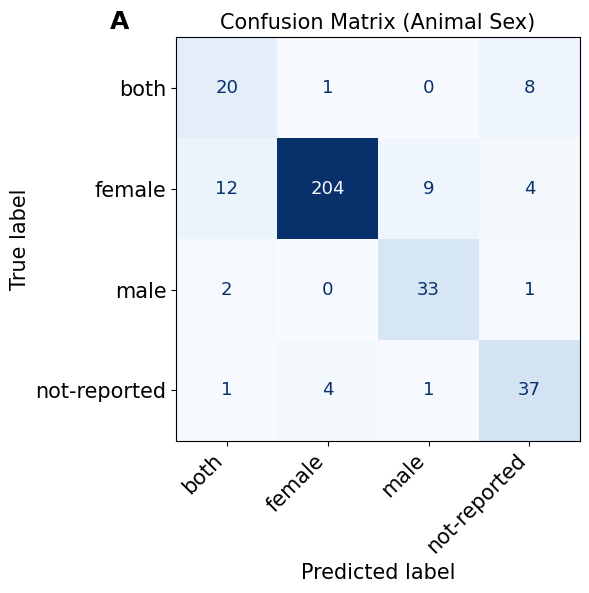

In [115]:
res = eval_categorical(
    df,
    target_col="Sex",
    pred_col="animal_sex",
    id_col="PMID",
    panel_label="A"
)

res["mismatches"].to_csv("./outputs/ms_hermes_annotations_validation/sex_mismatches.csv", index=False)

# Save all mismatches
res["mismatches"].to_csv(
    "./outputs/ms_hermes_annotations_validation/sex_mismatches.csv",
    index=False
)

# Save random sample of 5 (if at least 5 exist)
sample_n = min(5, len(res["mismatches"]))
res["mismatches"].sample(n=sample_n, random_state=42).to_csv(
    "./outputs/ms_hermes_annotations_validation/sex_mismatches_sample5.csv",
    index=False
)


### Species

                        precision    recall  f1-score   support

       dog, mouse, rat      0.000     0.000     0.000         0
            guinea pig      1.000     1.000     1.000         1
guinea pig, mouse, rat      0.000     0.000     0.000         0
                monkey      1.000     1.000     1.000         2
         monkey, mouse      0.000     0.000     0.000         0
    monkey, mouse, rat      0.000     0.000     0.000         0
                 mouse      0.996     0.948     0.971       268
            mouse, rat      0.000     0.000     0.000         0
        mouse, xenopus      0.000     0.000     0.000         1
                   rat      0.983     0.906     0.943        64
         species-other      0.000     0.000     0.000         0
             zebrafish      0.000     0.000     0.000         1

              accuracy                          0.935       337
             macro avg      0.332     0.321     0.326       337
          weighted avg      0.988     

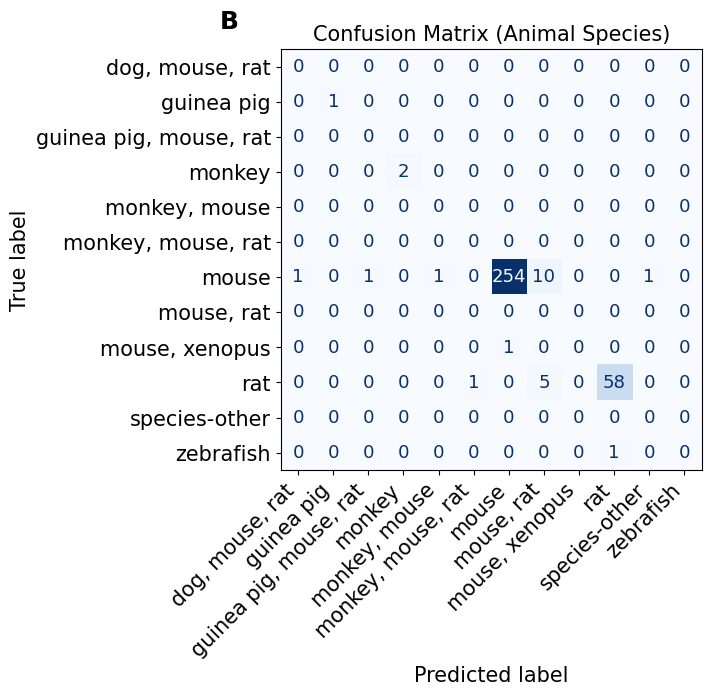

In [93]:
df["Species"] = df["Species"].replace("marmoset", "monkey")

res = eval_categorical(
    df,
    target_col="Species",
    pred_col="animal_species",
    id_col="pmid",
    panel_label="B",
    panel_loc_x=0.31
)
res["mismatches"].to_csv("./outputs/ms_hermes_annotations_validation/species_mismatches.csv")

### Strain

In [94]:
def evaluate_multilabel_sets(
    df: pd.DataFrame,
    true_col: str,
    pred_col: str,
    sep: str = ",",
    class_order: list[str] | None = None,
    show_per_class_report: bool = True,
    plot_per_class_confmat: bool = False,
    extra_cols: list[str] | None = None,   # e.g., ["pmid"]
    id_col: str | None = None              # e.g., "pmid"
):
    # --- helpers ---
    def _normalize(s: str) -> str:
        return s.strip().lower()

    def _split_set(x, sep=","):
        if pd.isna(x):
            return set()
        parts = [p for p in str(x).split(sep)]
        return {_normalize(p) for p in parts if _normalize(p)}

    # Resolve a column or index (case-insensitive); if not found and name == 'pmid',
    # fall back to using the index values and name it 'pmid'.
    colmap = {c.lower(): c for c in df.columns}
    def _get_series(name: str):
        if name is None:
            return None
        # exact column
        if name in df.columns:
            return df[name]
        # case-insensitive column
        low = name.lower()
        if low in colmap:
            return df[colmap[low]]
        # index name match (case-insensitive)
        if df.index.name and df.index.name.lower() == low:
            return pd.Series(df.index, index=df.index, name=df.index.name)
        # final fallback for 'pmid': use index even if unnamed
        if low == "pmid":
            return pd.Series(df.index, index=df.index, name="pmid")
        return None

    # Parse to sets
    y_true_sets = df[true_col].map(lambda x: _split_set(x, sep))
    y_pred_sets = df[pred_col].map(lambda x: _split_set(x, sep))

    # Row-level counts
    n_true = y_true_sets.map(len)
    n_pred = y_pred_sets.map(len)

    # Any-overlap & exact-set match
    any_overlap = pd.Series([(len(t & p) > 0) for t, p in zip(y_true_sets, y_pred_sets)], index=df.index)
    exact_match = pd.Series([(t == p) for t, p in zip(y_true_sets, y_pred_sets)], index=df.index)

    # Label universe
    if class_order is None:
        all_labels = sorted(set().union(*y_true_sets, *y_pred_sets))
    else:
        all_labels = list(class_order)

    # Binarize
    mlb = MultiLabelBinarizer(classes=all_labels)
    Y_true = mlb.fit_transform(y_true_sets)
    Y_pred = mlb.transform(y_pred_sets)

    # Metrics
    subset_acc = accuracy_score(Y_true, Y_pred)
    jaccard_samples = jaccard_score(Y_true, Y_pred, average="samples") if len(df) else 0.0
    prec_micro, rec_micro, f1_micro, _ = precision_recall_fscore_support(Y_true, Y_pred, average="micro", zero_division=0)
    prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(Y_true, Y_pred, average="macro", zero_division=0)
    prec_weighted, rec_weighted, f1_weighted, _ = precision_recall_fscore_support(Y_true, Y_pred, average="weighted", zero_division=0)

    class_report = None
    if show_per_class_report and len(all_labels) > 0:
        class_report = classification_report(Y_true, Y_pred, target_names=all_labels, zero_division=0, digits=3)

    per_class_conf = multilabel_confusion_matrix(Y_true, Y_pred, labels=range(len(all_labels)))

    stats = {
        "total_rows": int(len(df)),
        "any_overlap_accuracy": float(any_overlap.mean()) if len(df) else 0.0,
        "exact_match_accuracy": float(subset_acc),
        "jaccard_samples": float(jaccard_samples),
        "num_multi_pred": int((n_pred > 1).sum()),
        "rate_multi_pred": float((n_pred > 1).mean()) if len(df) else 0.0,
        "num_single_pred": int((n_pred == 1).sum()),
        "num_zero_pred": int((n_pred == 0).sum()),
        "num_multi_true": int((n_true > 1).sum()),
        "rate_multi_true": float((n_true > 1).mean()) if len(df) else 0.0,
        "precision_micro": float(prec_micro),
        "recall_micro": float(rec_micro),
        "f1_micro": float(f1_micro),
        "precision_macro": float(prec_macro),
        "recall_macro": float(rec_macro),
        "f1_macro": float(f1_macro),
        "precision_weighted": float(prec_weighted),
        "recall_weighted": float(rec_weighted),
        "f1_weighted": float(f1_weighted),
        "labels": all_labels,
    }

    # --- per-row overview (include extras + robust id handling) ---
    cols = {
        "true_raw": df[true_col],
        "pred_raw": df[pred_col],
        "true_set": y_true_sets,
        "pred_set": y_pred_sets,
        "n_true": n_true,
        "n_pred": n_pred,
        "any_overlap_correct": any_overlap,
        "exact_match": exact_match,
    }

    # Add extra columns (case-insensitive; column or index; pmid fallback)
    if extra_cols:
        for c in extra_cols:
            s = _get_series(c)
            if s is not None:
                cols[c] = s

    per_row = pd.DataFrame(cols)

    # Ensure id_col exists, then move first and set as index (keeping the column)
    if id_col:
        s = _get_series(id_col)
        if s is not None:
            per_row[id_col] = s
        if id_col in per_row.columns:
            ordered = [id_col] + [c for c in per_row.columns if c != id_col]
            per_row = per_row[ordered].set_index(id_col, drop=False)  # change to drop=True if you only want it as index

    if class_report:
        print(class_report)

    return stats, per_row, per_class_conf

In [95]:
df = ms_hermes_joined.copy()
df.head()

,PMID,title_x,DOI,Animal model,Species,Strain,Sex,Age,Tested drug(s),Comparator,Outcome,Total number of animals,title_y,merged_mondo_label,merged_umls_label,animal_species,animal_sex,animal_strain,animal_number
0,30185466,Reduced Microglial Activity and Enhanced Gluta...,10.1523/jneurosci.0398-18.2018,EAE,mouse,C57BL/6,female,9,Minocycline,control,not-reported,not-reported,Reduced Microglial Activity and Enhanced Gluta...,multiple sclerosis,mac1-saporin|Minocycline,mouse,female,C57BL/6,not-reported
1,23954214,Efficacy of vitamin D in treating multiple scl...,10.1016/j.expneurol.2013.08.002,EAE,rat,Dark Agouti,female,3,Vitamin D3,control,1.0,163.0,Efficacy of vitamin D in treating multiple scl...,multiple sclerosis|myeloid sarcoma|acute myelo...,VITAMIN D,rat,female,"Agouti,DA",not-reported
2,31715458,B cell function impacts the efficacy of IFN-Î²...,10.1016/j.jneuroim.2019.577106,EAE,mouse,C57BL/6,female,9,Interferon Beta 1,control,1.0,not-reported,B cell function impacts the efficacy of IFN-β ...,multiple sclerosis,beta Interferon,mouse,female,C57BL/6,not-reported
3,16148229,Neurogenesis and neuroprotection induced by pe...,10.1523/jneurosci.1859-05.2005,EAE,mouse,C57BL/6,female,9,Glatiramer acetate,control,1.0,not-reported,Neurogenesis and neuroprotection induced by pe...,multiple sclerosis,"Acetate, Glatiramer|Glatiramer",mouse,female,"C57BL/6,CBA/",not-reported
4,16365293,The immunomodulator glatiramer acetate augment...,10.1073/pnas.0509438102,EAE,mouse,"C57BL/6, (SJLxBALB/c)F1",female,10,Glatiramer acetate,control,1.0,not-reported,The immunomodulator glatiramer acetate augment...,multiple sclerosis,"ga|Acetate, Glatiramer|Glatiramer",mouse,female,"C57Bl,SJL",not-reported


In [98]:
import sys
from pathlib import Path

# In Jupyter, use the current working directory
CWD = Path().resolve()
TARGET_DIR = CWD.parent / "08_IE_full_text"

sys.path.insert(0, str(TARGET_DIR))

from map_strain_values import (
    build_lookup_table,
    normalize_animal_strains,
    postprocess_family_level
)

In [99]:
synonyms_file = "/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/08_IE_full_text/data/strain_normalization/combined_df_mice_rat.csv"
column = "Strain"
new_column = "Target_animal_strain_norm"
delimiter = ","
post_column = "Target_animal_strain_norm_family"

print(f"Loading synonym lookup from: {synonyms_file}")
canonical_lookup = build_lookup_table(synonyms_file)

# Normalize (fuzzy/synonym)
print(f"Normalizing strain names in column: {column}")
df = normalize_animal_strains(
    df,
    canonical_lookup,
    column=column,
    new_column=new_column,
    delimiter=delimiter,
)

# Post-process to family-level generic forms
post_col = post_column or f"{new_column}_family"
print(f"Post-processing to family-level in column: {post_col}")
df[post_col] = df[new_column].progress_apply(lambda x: postprocess_family_level(x, delimiter))



Loading synonym lookup from: /shares/animalwelfare.crs.uzh/Preclinical_Pipeline/08_IE_full_text/data/strain_normalization/combined_df_mice_rat.csv
Normalizing strain names in column: Strain


100%|██████████| 337/337 [00:00<00:00, 365.36it/s]


Post-processing to family-level in column: Target_animal_strain_norm_family


100%|██████████| 337/337 [00:00<00:00, 32257.25it/s]


In [100]:
df = df.replace("notreported", "not-reported")


In [101]:
df.head()

,PMID,title_x,DOI,Animal model,Species,Strain,Sex,Age,Tested drug(s),Comparator,...,Total number of animals,title_y,merged_mondo_label,merged_umls_label,animal_species,animal_sex,animal_strain,animal_number,Target_animal_strain_norm,Target_animal_strain_norm_family
0,30185466,Reduced Microglial Activity and Enhanced Gluta...,10.1523/jneurosci.0398-18.2018,EAE,mouse,C57BL/6,female,9,Minocycline,control,...,not-reported,Reduced Microglial Activity and Enhanced Gluta...,multiple sclerosis,mac1-saporin|Minocycline,mouse,female,C57BL/6,not-reported,C57BL/6-Tg(Scgb1a1-TFRC/OVA)1Adl/Bmed,C57BL/6
1,23954214,Efficacy of vitamin D in treating multiple scl...,10.1016/j.expneurol.2013.08.002,EAE,rat,Dark Agouti,female,3,Vitamin D3,control,...,163.0,Efficacy of vitamin D in treating multiple scl...,multiple sclerosis|myeloid sarcoma|acute myelo...,VITAMIN D,rat,female,"Agouti,DA",not-reported,DA,DA
2,31715458,B cell function impacts the efficacy of IFN-Î²...,10.1016/j.jneuroim.2019.577106,EAE,mouse,C57BL/6,female,9,Interferon Beta 1,control,...,not-reported,B cell function impacts the efficacy of IFN-β ...,multiple sclerosis,beta Interferon,mouse,female,C57BL/6,not-reported,C57BL/6-Tg(Scgb1a1-TFRC/OVA)1Adl/Bmed,C57BL/6
3,16148229,Neurogenesis and neuroprotection induced by pe...,10.1523/jneurosci.1859-05.2005,EAE,mouse,C57BL/6,female,9,Glatiramer acetate,control,...,not-reported,Neurogenesis and neuroprotection induced by pe...,multiple sclerosis,"Acetate, Glatiramer|Glatiramer",mouse,female,"C57BL/6,CBA/",not-reported,C57BL/6-Tg(Scgb1a1-TFRC/OVA)1Adl/Bmed,C57BL/6
4,16365293,The immunomodulator glatiramer acetate augment...,10.1073/pnas.0509438102,EAE,mouse,"C57BL/6, (SJLxBALB/c)F1",female,10,Glatiramer acetate,control,...,not-reported,The immunomodulator glatiramer acetate augment...,multiple sclerosis,"ga|Acetate, Glatiramer|Glatiramer",mouse,female,"C57Bl,SJL",not-reported,"C57BL/6-Tg(Scgb1a1-TFRC/OVA)1Adl/Bmed,(SJLxBAL...","C57BL/6,F1"


In [102]:
stats, per_row, per_class = evaluate_multilabel_sets(
    df,
    true_col="Target_animal_strain_norm_family",
    pred_col="animal_strain",
    sep=",",
    extra_cols=["pmid"],   # include pmid in the overview
    id_col="pmid"          # show pmid as the index/first column
)

print(stats["any_overlap_accuracy"])


                           precision    recall  f1-score   support

                      129      0.000     0.000     0.000         0
                        2      0.000     0.000     0.000         0
                       2d      0.000     0.000     0.000         0
                      2d2      0.000     0.000     0.000         0
                     2d2t      0.000     0.000     0.000         0
                       2s      0.000     0.000     0.000         0
                   8wkold      0.000     0.000     0.000         0
                       a/      0.000     0.000     0.000         0
                      abh      0.000     0.000     0.000         0
                   agouti      0.000     0.000     0.000         0
         b10d1ih2supq/sup      0.000     0.000     0.000         0
b10plih2supu/suph2t18supa      0.588     1.000     0.741        10
                    b10ri      0.000     0.000     0.000         0
                  b10riii      1.000     1.000     1.000     

In [28]:
# Peek at rows with mismatches, but include pmid:
per_row[~per_row["any_overlap_correct"]].to_csv("./outputs/ms_hermes_annotations_validation/strain_mismatches.csv")
per_row[~per_row["any_overlap_correct"]].head()

,pmid,true_raw,pred_raw,true_set,pred_set,n_true,n_pred,any_overlap_correct,exact_match
pmid,,,,,,,,,
16365293,16365293,"C57BL/6,F1","C57Bl,Sj","{f1, c57bl/6}","{c57bl, sj}",2,2,False,False
12020957,12020957,F1,SjlJ,{f1},{sjlj},1,1,False,False
21752599,21752599,F1,"C57BL/6,SJL",{f1},"{sjl, c57bl/6}",1,2,False,False
21459808,21459808,BiozziABH,not-reported,{biozziabh},{not-reported},1,1,False,False
22547654,22547654,not-reported,BALB/C,{not-reported},{balb/c},1,1,False,False


### Animal nr

In [103]:
import unicodedata

def normalize_text(s):
    if isinstance(s, str):
        s = unicodedata.normalize("NFKC", s.strip().lower())
        s = s.replace("‐", "-")  # replace Unicode hyphen with ASCII
    return s

df["Total number of animals"] = df["Total number of animals"].apply(normalize_text)
df["animal_number"] = df["animal_number"].apply(normalize_text)

In [104]:
def eval_animal_number(
    df,
    true_col="Total number of animals",
    pred_col="animal_number",
    atol=1e-9
):
    """
    Evaluates numeric predictions vs. true totals.
    exact_match = single prediction == true
    partial_match = true in predictions AND more than one prediction
    """
    def parse_preds(val):
        if pd.isna(val):
            return []
        if isinstance(val, (list, tuple, np.ndarray)):
            return [float(v) for v in val if pd.notna(v)]
        if isinstance(val, str):
            try:
                parsed = ast.literal_eval(val)
                if isinstance(parsed, (list, tuple)):
                    return [float(v) for v in parsed]
                else:
                    return [float(parsed)]
            except Exception:
                nums = re.findall(r'[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?', val)
                return [float(n) for n in nums] if nums else []
        try:
            return [float(val)]
        except Exception:
            return []

    rows = []
    for _, r in df.iterrows():
        true_val = float(r[true_col])
        raw_pred = r[pred_col]
        preds = parse_preds(raw_pred)

        best_pred = np.nan
        abs_error = np.nan
        rel_error = np.nan
        exact_match = False
        partial_match = False
        contains_true = any(isclose(p, true_val, abs_tol=atol) for p in preds)

        if preds:
            errors = [abs(p - true_val) for p in preds]
            j = int(np.argmin(errors))
            best_pred = preds[j]
            abs_error = errors[j]
            rel_error = abs_error / true_val if true_val else np.nan

            if contains_true:
                if len(preds) == 1:
                    exact_match = True
                elif len(preds) > 1:
                    partial_match = True

        # others relative to true
        others = [p for p in preds if not isclose(p, true_val, abs_tol=atol)]
        other_preds_below_true = [p for p in others if p < true_val] or None
        other_preds_above_true = [p for p in others if p > true_val] or None

        rows.append({
            "true": true_val,
            "pred_raw": raw_pred,
            "best_pred": best_pred,
            "abs_error": abs_error,
            "rel_error": rel_error,
            "exact_match": exact_match,
            "partial_match": partial_match,
            "other_preds_below_true": other_preds_below_true,
            "other_preds_above_true": other_preds_above_true,
        })

    per_row = pd.DataFrame(rows)

    summary = {
        "n": len(per_row),
        "n_exact_match": int(per_row["exact_match"].sum()),
        "exact_match_rate": per_row["exact_match"].mean(),
        "n_partial_match": int(per_row["partial_match"].sum()),
        "partial_match_rate": per_row["partial_match"].mean(),
        "mean_abs_error": per_row["abs_error"].mean(),
        "median_abs_error": per_row["abs_error"].median(),
        "mean_rel_error": per_row["rel_error"].mean(),
    }

    return summary, per_row

In [105]:
def extract_max_animal_number(val):
    # Handle missing values
    if pd.isna(val):
        return None
    
    # Case 1: actual Python list
    if isinstance(val, (list, tuple)):
        return max(val)
    
    # Case 2: string like "[10, 12,30]"
    if isinstance(val, str):
        try:
            parsed = ast.literal_eval(val)
            if isinstance(parsed, (list, tuple)) and all(isinstance(x, (int, float)) for x in parsed):
                return max(parsed)
        except Exception:
            pass  # Not a valid list string
        
        # If it's just a single number string like "15"
        try:
            return float(val)
        except ValueError:
            return None
    
    return None

In [106]:
def to_number(val):
    """Convert value to number, return 0 for non-numeric or 'not-reported'."""
    if pd.isna(val):
        return 0
    if isinstance(val, (int, float)):
        return val
    val = str(val).strip().lower()
    if val in ["not-reported", "not reported", "na", "nan", "none", ""]:
        return 0
    try:
        return float(val)
    except ValueError:
        return 0

# Apply conversion
ms_hermes_joined["Total number of animals (num)"] = ms_hermes_joined["Total number of animals"].apply(to_number)

# Get total sum
total_animals = ms_hermes_joined["Total number of animals (num)"].sum()

print(f"Total number of animals across dataset: {int(total_animals)}")

Total number of animals across dataset: 6400


In [107]:
len(ms_hermes_joined[ms_hermes_joined["Total number of animals"]!= "not-reported"])

105

In [108]:
len(ms_hermes_joined[ms_hermes_joined["animal_number"]!= "not-reported"])

63

In [109]:
len(ms_hermes_joined[ms_hermes_joined["animal_number"]== "not-reported"])

274

In [110]:
ms_hermes_joined["animal_number_max"] = ms_hermes_joined["animal_number"].apply(extract_max_animal_number)

# Apply conversion
ms_hermes_joined["Total predicted number of animals (num)"] = ms_hermes_joined["animal_number_max"].apply(to_number)

# Get total sum
total_animals_predicted = ms_hermes_joined["Total predicted number of animals (num)"].sum()

print(f"Total number of animals across dataset: {int(total_animals_predicted)}")

Total number of animals across dataset: 4195


In [111]:
filtered_animal_nr_both_labeled = ms_hermes_joined[
    (ms_hermes_joined["Total number of animals"] != "not-reported") &
    (ms_hermes_joined["animal_number"] != "not-reported")
]

In [112]:
filtered_animal_nr_both_labeled.head()

,PMID,title_x,DOI,Animal model,Species,Strain,Sex,Age,Tested drug(s),Comparator,...,title_y,merged_mondo_label,merged_umls_label,animal_species,animal_sex,animal_strain,animal_number,Total number of animals (num),animal_number_max,Total predicted number of animals (num)
18,26198937,Fingolimod does not enhance cerebellar remyeli...,10.1016/j.jneuroim.2015.06.006,cuprizone,mouse,C57BL/6,female,5,Fingolimod,control,...,Fingolimod does not enhance cerebellar remyeli...,relapsing-remitting multiple sclerosis|multipl...,Fingolimod|FTY-720,mouse,female,C57BL/6,32.0,32.0,32.0,32.0
34,30524355,Regular Exercise Modifies Histopathological Ou...,10.3389/fneur.2018.00950,EAE,mouse,C57BL/6,female,5,"Dimethyl fumarate, Glatiramer acetate",control,...,Regular Exercise Modifies Histopathological Ou...,multiple sclerosis,"Fumarate, Dimethyl|Acetate, Glatiramer|Glatiramer",mouse,female,C57BL/6,96.0,96.0,96.0,96.0
38,21615449,Glatiramer acetate-specific antibody titres in...,10.1111/j.1365-3083.2011.02581.x,EAE,mouse,C57BL/6,female,7,Glatiramer acetate,control,...,Glatiramer acetate-specific antibody titres in...,relapsing-remitting multiple sclerosis|clinica...,"Acetate, Glatiramer|Glatiramer",mouse,female,C57BL/6,12.0,12.0,12.0,12.0
41,9394786,"Synergism between sirolimus and 1,25-dihydroxy...",10.1016/s0165-5728(97)00116-1,EAE,mouse,SJL,male,9,Vitamin D3,control,...,NaN,NaN,NaN,mouse,male,"NMRI,SJL","[308.0, 42.0]",308.0,308.0,308.0
66,32871475,"A new lipophilic amino alcohol, chemically sim...",10.1016/j.intimp.2020.106919,EAE,mouse,C57BL/6,female,7,Fingolimod,control,...,"A new lipophilic amino alcohol, chemically sim...",multiple sclerosis,lipophilic amino alcohol 4b|chain lipophilic a...,mouse,female,"BALB/C,C57BL/6",68.0,68.0,68.0,68.0


In [114]:
summary, details = eval_animal_number(filtered_animal_nr_both_labeled,
                                      true_col="Total number of animals",
                                      pred_col="animal_number_max")

summary


{'n': 51,
 'n_exact_match': 42,
 'exact_match_rate': 0.8235294117647058,
 'n_partial_match': 0,
 'partial_match_rate': 0.0,
 'mean_abs_error': 2.795918367346939,
 'median_abs_error': 0.0,
 'mean_rel_error': 0.05894937323508752}

In [40]:
details.to_csv("./outputs/ms_hermes_annotations_validation/animals_nr_predictions.csv", index=False)

In [ ]:
print(details.head())

In [41]:
details.head()

,true,pred_raw,best_pred,abs_error,rel_error,exact_match,partial_match,other_preds_below_true,other_preds_above_true
0,85.0,85.0,85.0,0.0,0.0,True,False,None,None
1,32.0,32.0,32.0,0.0,0.0,True,False,None,None
2,96.0,96.0,96.0,0.0,0.0,True,False,None,None
3,12.0,12.0,12.0,0.0,0.0,True,False,None,None
4,308.0,308.0,308.0,0.0,0.0,True,False,None,None


In [42]:
filtered_animal_nr_pred_only = ms_hermes_joined[
    (ms_hermes_joined["Total number of animals"] == "not-reported") &
    (ms_hermes_joined["animal_number"] != "not-reported")
]
filtered_animal_nr_pred_only[['PMID','Total number of animals', 'animal_number']]
filtered_animal_nr_pred_only[['PMID','Total number of animals', 'animal_number']].to_csv("./outputs/ms_hermes_annotations_validation/animals_nr_predictions_FP.csv",index=False)

In [43]:
filtered_animal_nr_pred_only.shape

(11, 23)

In [44]:
filtered_animal_nr_pred_missing = ms_hermes_joined[
    (ms_hermes_joined["Total number of animals"] != "not-reported") &
    (ms_hermes_joined["animal_number"] == "not-reported")
]
filtered_animal_nr_pred_missing[['PMID','Total number of animals', 'animal_number']]
filtered_animal_nr_pred_missing[['PMID','Total number of animals', 'animal_number']].to_csv("./outputs/ms_hermes_annotations_validation/animals_nr_predictions_FN.csv",index=False)

In [45]:
filtered_animal_nr_pred_missing.shape

(62, 23)

# RoB

In [155]:
def normalize_label(x):
    if pd.isna(x):
        return "not-reported"
    
    x = str(x).strip().lower()
    
    if x in ["yes", "present", "reported"]:
        return "present"
    
    if "present" in x:
        return "present"
    
    return "not-reported"


In [176]:
def eval_categorical_grid_2x2(
    df: pd.DataFrame,
    specs,                     # list of dicts: target_col, pred_col, panel_label, title
    class_order=None,
    normalize=None,
    dropna: bool = True,
    print_report: bool = True,
    id_col: str = "pmid",
    font_size: int = 15,
    title_font_size: int = 15,
    panel_font_size: int = 18,
    savepath: str = "viz/rob_conf_matrices_2x2.pdf",
):
    """
    Plot 4 confusion matrices in a single 2x2 grid (A–D) and return mismatches per panel.
    """

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.ravel()

    results = {}

    for i, spec in enumerate(specs):
        ax = axes[i]
        target_col = spec["target_col"]
        pred_col = spec["pred_col"]
        panel_label = spec.get("panel_label", None)
        panel_title = spec.get("title", f"{target_col} vs {pred_col}")

        y_true = df[target_col]
        y_pred = df[pred_col]

        if dropna:
            mask = y_true.notna() & y_pred.notna()
            y_true_i = y_true[mask]
            y_pred_i = y_pred[mask]
            df_i = df.loc[mask]
        else:
            y_true_i = y_true
            y_pred_i = y_pred
            df_i = df

        # classes
        if class_order is not None:
            classes = list(class_order)
        else:
            classes = sorted(pd.unique(pd.concat([y_true_i, y_pred_i], ignore_index=True)))

        if len(classes) == 0:
            raise ValueError(f"No classes found for {target_col} vs {pred_col} after filtering.")

        if print_report:
            print(f"\n=== {panel_title} ===")
            print(classification_report(y_true_i, y_pred_i, labels=classes, zero_division=0, digits=3))

        cm = confusion_matrix(y_true_i, y_pred_i, labels=classes, normalize=normalize)
        values_format = None if normalize else "d"

        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
        disp.plot(cmap="Blues", values_format=values_format, ax=ax, colorbar=False)

        # tidy fonts
        ax.set_title(panel_title + (f"\n(normalized={normalize})" if normalize else ""), fontsize=title_font_size)
        ax.set_xlabel("Predicted", fontsize=font_size)
        ax.set_ylabel("True", fontsize=font_size)
        ax.tick_params(axis="x", labelrotation=45, labelsize=font_size)
        ax.tick_params(axis="y", labelsize=font_size)

        for t in ax.texts:
            t.set_fontsize(font_size - 2)

        # panel label (A/B/C/D) in upper-left of each subplot
        if panel_label is not None:
            ax.text(
                -0.15, 1.08, panel_label,
                transform=ax.transAxes,
                fontsize=panel_font_size,
                fontweight="bold",
                va="top",
                ha="left"
            )

        mismatches = df_i[df_i[target_col] != df_i[pred_col]].copy()
        if id_col in mismatches.columns:
            mismatches = mismatches[[id_col, target_col, pred_col]]
        else:
            mismatches = mismatches[[target_col, pred_col]]

        results[panel_label or panel_title] = {
            "classes": classes,
            "confusion_matrix": cm,
            "mismatches": mismatches,
        }

    # hide any unused axes (if specs < 4)
    for j in range(len(specs), 4):
        axes[j].axis("off")

    plt.tight_layout()
    plt.savefig(savepath)
    plt.show()

    return results

In [177]:
ms_hermes_with_rob = ms_hermes_joined[ms_hermes_joined["doi"].notna() & (ms_hermes_joined["doi"].str.strip() != "")][['PMID','Randomization','Blinding','Samplesize','Welfare','rigor_randomization','rigor_blinding','rigor_welfare','sample_size']]
ms_hermes_with_rob.head()

,PMID,Randomization,Blinding,Samplesize,Welfare,rigor_randomization,rigor_blinding,rigor_welfare,sample_size
10,30858445,yes,not-reported,not-reported,yes,randomization-not-reported,blinding-not-reported,welfare-present,sample-size-not-reported
18,26198937,yes,yes,not-reported,yes,randomization-not-reported,blinding-present,welfare-present,sample-size-not-reported
19,25493280,not-reported,not-reported,not-reported,yes,randomization-not-reported,blinding-not-reported,welfare-present,sample-size-not-reported
20,15378653,not-reported,not-reported,not-reported,not-reported,randomization-not-reported,blinding-not-reported,welfare-present,sample-size-not-reported
23,27864936,yes,yes,not-reported,yes,randomization-present,blinding-present,welfare-present,sample-size-not-reported


In [181]:
ms_hermes_with_rob.shape

(64, 9)

In [178]:
cols_to_normalize = [
    "Randomization",
    "Blinding",
    "Samplesize",
    "Welfare",
    "rigor_randomization",
    "rigor_blinding",
    "rigor_welfare",
    "sample_size"
]

for col in cols_to_normalize:
    ms_hermes_with_rob[col] = ms_hermes_with_rob[col].apply(normalize_label)
ms_hermes_with_rob

,PMID,Randomization,Blinding,Samplesize,Welfare,rigor_randomization,rigor_blinding,rigor_welfare,sample_size
10,30858445,present,not-reported,not-reported,present,not-reported,not-reported,present,not-reported
18,26198937,present,present,not-reported,present,not-reported,present,present,not-reported
19,25493280,not-reported,not-reported,not-reported,present,not-reported,not-reported,present,not-reported
20,15378653,not-reported,not-reported,not-reported,not-reported,not-reported,not-reported,present,not-reported
23,27864936,present,present,not-reported,present,present,present,present,not-reported
...,...,...,...,...,...,...,...,...,...
306,25727069,not-reported,not-reported,present,present,not-reported,present,present,not-reported
307,23939596,not-reported,not-reported,not-reported,present,not-reported,not-reported,not-reported,not-reported
308,31821174,not-reported,not-reported,not-reported,not-reported,not-reported,present,not-reported,not-reported
318,26475743,not-reported,present,not-reported,present,not-reported,present,present,not-reported



=== Welfare ===
              precision    recall  f1-score   support

not-reported      0.778     0.636     0.700        11
     present      0.927     0.962     0.944        53

    accuracy                          0.906        64
   macro avg      0.853     0.799     0.822        64
weighted avg      0.902     0.906     0.902        64


=== Randomization ===
              precision    recall  f1-score   support

not-reported      0.788     1.000     0.882        41
     present      1.000     0.522     0.686        23

    accuracy                          0.828        64
   macro avg      0.894     0.761     0.784        64
weighted avg      0.864     0.828     0.811        64


=== Blinding ===
              precision    recall  f1-score   support

not-reported      1.000     0.930     0.964        43
     present      0.875     1.000     0.933        21

    accuracy                          0.953        64
   macro avg      0.938     0.965     0.949        64
weighted avg    

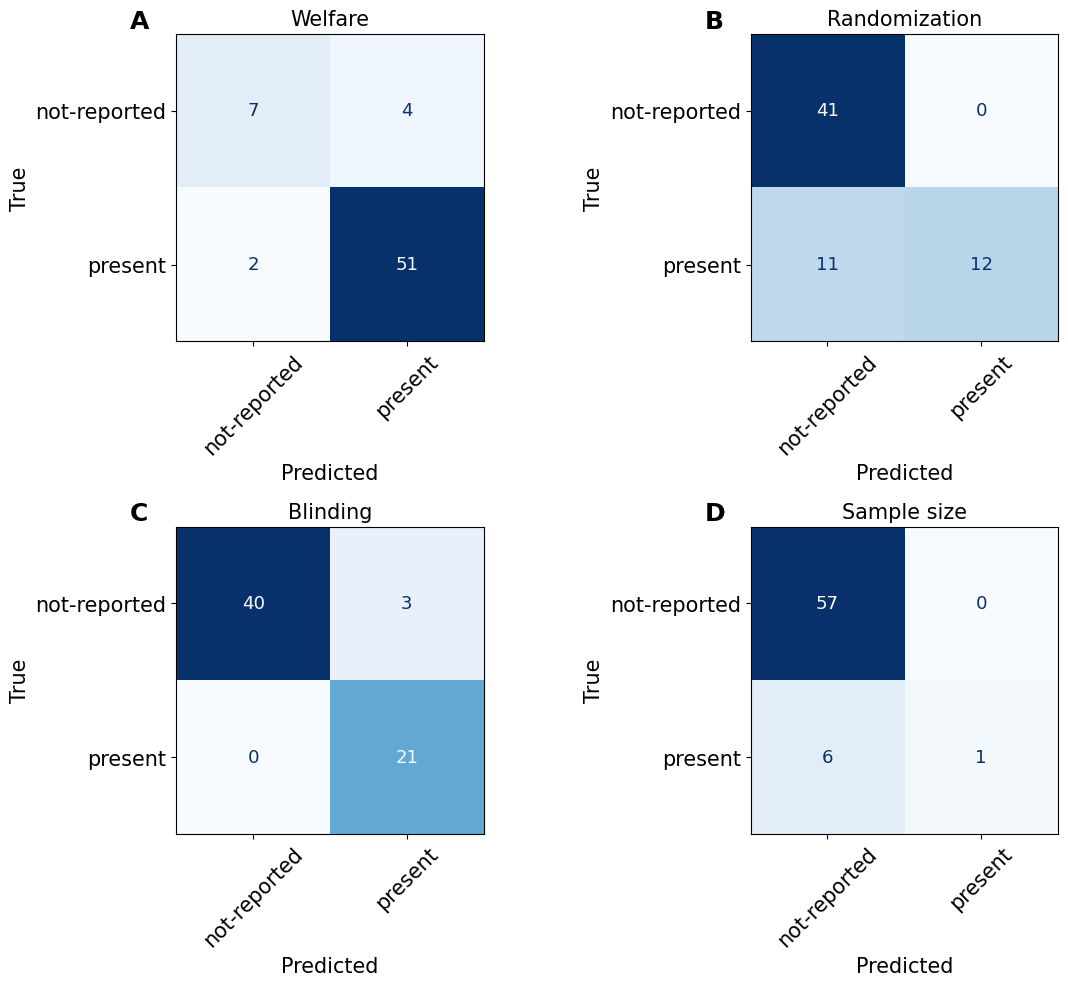

In [180]:
specs = [
    {"target_col": "Welfare",       "pred_col": "rigor_welfare",        "panel_label": "A", "title": "Welfare"},
    {"target_col": "Randomization", "pred_col": "rigor_randomization",  "panel_label": "B", "title": "Randomization"},
    {"target_col": "Blinding",      "pred_col": "rigor_blinding",       "panel_label": "C", "title": "Blinding"},
    {"target_col": "Samplesize",    "pred_col": "sample_size",         "panel_label": "D", "title": "Sample size"},
]

rob_res = eval_categorical_grid_2x2(
    ms_hermes_with_rob,
    specs=specs,
    id_col="PMID",
    normalize=None,                 # or "true"/"pred"/"all"
    dropna=True,
    print_report=True,
    savepath="viz/rob_elements_confusion_2x2.pdf",
)


              precision    recall  f1-score   support

not-reported      0.788     1.000     0.882        41
     present      1.000     0.522     0.686        23

    accuracy                          0.828        64
   macro avg      0.894     0.761     0.784        64
weighted avg      0.864     0.828     0.811        64



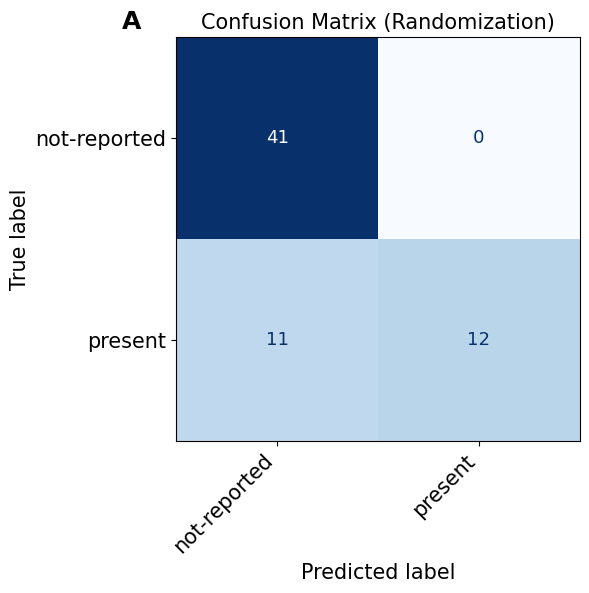

In [174]:
res = eval_categorical(
    ms_hermes_with_rob,
    target_col="Randomization",
    pred_col="rigor_randomization",
    id_col="PMID",
    panel_label="A",
    panel_loc_x=0.21,
    animal_title=False
)
res["mismatches"].to_csv("./outputs/ms_hermes_annotations_validation/randomization_mismatches.csv", index=False)

In [175]:
sample_n = min(5, len(res["mismatches"]))
res["mismatches"].sample(n=sample_n, random_state=42).to_csv(
    "./outputs/ms_hermes_annotations_validation/randomization_mismatches_sample5.csv",
    index=False
)


# Drug

In [227]:
from transformers import AutoTokenizer, AutoModel


In [228]:
ms_hermes_joined_drugs = ms_hermes_joined[['PMID','Tested drug(s)','drug_term_umls_norm']]

In [229]:
CURRENT_DIR = Path().resolve()
NORM_MODULE_PATH = CURRENT_DIR.parent / "04_normalization"
sys.path.insert(0, str(NORM_MODULE_PATH))

from neural_based_nen import map_query_to_terminology

In [230]:
CURRENT_DIR = Path().resolve().parent
NORM_MODULE_PATH = CURRENT_DIR.parent / "04_normalization"
sys.path.insert(0, str(NORM_MODULE_PATH))
from neural_based_nen import map_query_to_terminology

TERMINOLOGY = "umls"
DIST_THRESHOLD = 7.8
EMBEDDINGS_DIR = f"/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/04_normalization/data/{TERMINOLOGY}/embeddings"
BATCH_PREFIX = "UMLS_emb"
TERM_ID_FILE = f"/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/04_normalization/data/{TERMINOLOGY}/umls_term_id_pairs.json"
ID_TO_TERM_MAP = f"/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/04_normalization/data/{TERMINOLOGY}/{TERMINOLOGY}_id_to_term_map.json"

# --- Load embeddings ---
embedding_files = sorted([
    os.path.join(EMBEDDINGS_DIR, f) for f in os.listdir(EMBEDDINGS_DIR)
    if f.startswith(f"{BATCH_PREFIX}_batch_") and f.endswith(".npy")
])
all_embeddings = [np.load(f) for f in embedding_files]
embeddings_to_use = np.concatenate(all_embeddings, axis=0)

# --- Load mapping and metadata ---
with open(TERM_ID_FILE, "r") as f:
    corresponding_term_id = json.load(f)

with open(ID_TO_TERM_MAP, "r", encoding="utf-8") as f:
    canonical_mapping_dict = json.load(f)

# --- Load model ---
tokenizer = AutoTokenizer.from_pretrained("cambridgeltl/SapBERT-from-PubMedBERT-fulltext")
model = AutoModel.from_pretrained("cambridgeltl/SapBERT-from-PubMedBERT-fulltext")



/home/sdonev/.local/lib/python3.11/site-packages/huggingface_hub/file_download.py:896: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [231]:
query = "vitamin D" # fingolimod-1 phosphate, fty720-c2
predicted_id, predicted_label, canonical_form, nearest_3, nn_dist = map_query_to_terminology(
        query,
        tokenizer,
        model,
        embeddings_to_use,
        corresponding_term_id,
        canonical_mapping_dict,
        dist_threshold=DIST_THRESHOLD
    )
nearest_3, canonical_form

([['VITAMIN D', 'C3714503'],
  ['Vitamin D', 'C0042866'],
  ['CALCIUM/VITAMIN D', 'C0719107'],
  ['VITAMIN D,OTHER', 'C1875862'],
  ['vitamin D3', 'C3265062']],
 'VITAMIN D')

In [232]:
query = "4-aminopyridine" # 4-AP
predicted_id, predicted_label, canonical_form, nearest_3, nn_dist = map_query_to_terminology(
        query,
        tokenizer,
        model,
        embeddings_to_use,
        corresponding_term_id,
        canonical_mapping_dict,
        dist_threshold=DIST_THRESHOLD
    )
nearest_3, canonical_form

([['Aminopyridine', 'C0002585'],
  ['Aminopyridine', 'C0002584'],
  ['alpha-aminopyridine', 'C0051326'],
  ['3-aminopyridine', 'C0047238'],
  ['4-amino-2-iminopyridine', 'C3850632']],
 'Aminopyridine')

In [233]:
def normalize_tested_drugs_cell(
    cell: str,
    tokenizer,
    model,
    embeddings_to_use,
    corresponding_term_id,
    canonical_mapping_dict,
    dist_threshold: float
) -> str:
    """
    Normalize a comma-separated string of drugs into a '|' separated string of canonical names.
    - Keeps original term when map_query_to_terminology returns -1 (your function already does that).
    - Deduplicates while preserving order.
    - Handles NaN / empty cells gracefully.
    """
    if pd.isna(cell) or not isinstance(cell, str):
        return ""

    # Split by commas or | sign (tolerate extra spaces); ignore empty chunks
    parts = [p.strip() for p in re.split(r"\s*[|,]\s*", str(cell)) if p.strip()]

    if not parts:
        return ""

    canonicals = []
    seen = set()
    for query in parts:
        predicted_id, predicted_label, canonical_form, nearest_3, nn_dist = map_query_to_terminology(
            query,
            tokenizer,
            model,
            embeddings_to_use,
            corresponding_term_id,
            canonical_mapping_dict,
            dist_threshold=dist_threshold
        )
        # Use canonical_form (your function already falls back to original query if no mapping)
        if canonical_form not in seen:
            seen.add(canonical_form)
            canonicals.append(canonical_form)

    # Join canonicals with pipe
    return "|".join(canonicals)



In [234]:
# Apply to your DataFrame
# Assumes you already have: tokenizer, model, embeddings_to_use, corresponding_term_id, canonical_mapping_dict, DIST_THRESHOLD
ms_hermes_joined_drugs["unique_drug_target"] = ms_hermes_joined_drugs["Tested drug(s)"].progress_apply(
    lambda cell: normalize_tested_drugs_cell(
        cell,
        tokenizer,
        model,
        embeddings_to_use,
        corresponding_term_id,
        canonical_mapping_dict,
        dist_threshold=DIST_THRESHOLD
    )
)

100%|██████████| 354/354 [04:41<00:00,  1.26it/s]
/sctmp/sdonev/ipykernel_1819180/2574029870.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ms_hermes_joined_drugs["unique_drug_target"] = ms_hermes_joined_drugs["Tested drug(s)"].progress_apply(


In [235]:
ms_hermes_joined_drugs.to_csv("./outputs/ms_hermes_annotations_validation/drugs_normalized_df.csv",index=False)

In [236]:
PRECLINICAL_METADATA_PATH = "/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/03_IE_ner/data/animal_studies_with_drug_disease/animal_studies_metadata_595768.csv"
# load data
metadata_df = pd.read_csv(PRECLINICAL_METADATA_PATH)[['PMID','unique_interventions_linkbert_predictions']]
metadata_df = metadata_df.drop_duplicates(subset=['PMID'])


In [237]:
metadata_df[metadata_df['PMID'].duplicated(keep=False)].sort_values('PMID')


,PMID,unique_interventions_linkbert_predictions


In [238]:
ms_hermes_joined_drugs = ms_hermes_joined_drugs.merge(metadata_df, on="PMID", how="left")

In [239]:
ms_hermes_joined_drugs[ms_hermes_joined_drugs["Tested drug(s)"].astype(str).str.contains(r"\|")]

,PMID,Tested drug(s),drug_term_umls_norm,unique_drug_target,unique_interventions_linkbert_predictions
15,32214838,Rituximab|Monomethyl fumarate,riTUXimab,riTUXimab|Monomethyl fumarate,rituximab
17,26580651,Vitamin D3|Monomethyl fumarate,"Monomethyl fumarate|1alpha,25-dihydroxyvitamin...",vitamin D3|Monomethyl fumarate,"monomethyl fumarate|vitamin d3|1α , 25-dihydro..."
18,36688131,Vitamin D3|Siponimod,sipo|vitamin D3|siponimod|Cholecalciferol,vitamin D3|siponimod,sipo|vitamin d3|siponimod|vit d3
20,25493280,Rituximab|Fingolimod,CD20Bi antibody|CD20Bi antibody|fty720-c2|Anti...,riTUXimab|Fingolimod,fty720|anti cd20|anti-cd20|cd20
27,11160259,Estriol|Estriol,Estriol|Estradiol|Estrogens,Estriol,NaN
64,20955831,Fingolimod|Interferon Beta 1,sphingosine 1-phosphate receptor modulator|rm-...,Fingolimod|beta 1 Interferon,NaN
74,26692368,Fingolimod|Dimethyl fumarate,"Fumarate, Dimethyl|Fingolimod|Fumarate, Dimeth...","Fingolimod|Fumarate, Dimethyl",dmf|dimethyl fumarate|fingolimod|fty720
78,32293668,Fampridine|Fingolimod,Dalfampridine|Aminopyridine|Fingolimod,Fampridine|Fingolimod,fingolimod|4-aminopyridine
87,27718209,Natalizumab|Dimethyl fumarate,"Natalizumab|Fumarate, Dimethyl|Acetylcysteine","Natalizumab|Fumarate, Dimethyl",dimethyl fumarate|n-acetyl-cysteine|natalizumab
105,15958276,Minocycline|Interferon Beta 1,Interferon beta (recombinant)|Minocycline,Minocycline|beta 1 Interferon,minocycline|interferon-beta


In [240]:
ms_hermes_joined_drugs.to_csv("./outputs/ms_hermes_annotations_validation/drugs_normalized_df_all_annotations.csv",index=False)

#### start here if drugs already mapped

In [185]:
def compute_annotations(row, entity, model, pred_column):

    target_col = f'unique_{entity.replace("_v1","").replace("_v2","")}_target'
    model_col = pred_column #"drug_term_umls_norm"#f'unique_{entity}_{model}'
    
    target_entities = (
        [] if pd.isna(row[target_col]) or str(row[target_col]).strip() == ""
        else str(row[target_col]).split('|')
    )
    # IGNORE ABBREVIATIONS
    target_entities = [e for e in target_entities if len(e) > 2]

    predicted_entities = (
        [] if pd.isna(row[model_col]) or str(row[model_col]).strip() == ""
        else str(row[model_col]).split('|')
    )
    # IGNORE ABBREVIATIONS
    predicted_entities = [e for e in predicted_entities if len(e) > 2]

    if not target_entities or not predicted_entities:
        return handle_empty_arrays(target_entities, predicted_entities)

    # Create a set of all unique entities from both target and predicted for consistent indexing
    all_entities = set(target_entities + predicted_entities)

    # Target annotations (exact)
    target_annotations_exact = [1 if entity in target_entities else 0 for entity in all_entities]

    # Predicted annotations (exact)
    predicted_annotations_exact = [1 if entity in predicted_entities else 0 for entity in all_entities]

    # Target annotations (partial)
    target_annotations_partial = [1 if any(partial_match(entity, target_ent) for target_ent in target_entities) else 0 for entity in all_entities]

    # Predicted annotations (partial)
    predicted_annotations_partial = [1 if any(partial_match(entity, pred) for pred in predicted_entities) else 0 for entity in all_entities]

    return pd.Series([
        target_annotations_exact,
        predicted_annotations_exact,
        target_annotations_partial,
        predicted_annotations_partial
    ], index=[
        f'target_{entity}_annotations_exact_{model}',
        f'predicted_{entity}_annotations_exact_{model}',
        f'target_{entity}_annotations_partial_{model}',
        f'predicted_{entity}_annotations_partial_{model}'
    ])

In [186]:
def partial_match_simple(predicted, target):
    predicted_parts = predicted.lower().split()
    target_parts = target.lower().split()
    return any(pred_part in target_part or target_part in pred_part for pred_part in predicted_parts for target_part in target_parts)

# Function to check for partial matches using difflib
def partial_match(predicted, target, cutoff=0.6):
    # Split the conditions into individual terms
    predicted_terms = predicted.split('|')
    target_terms = target.split('|')
    
    # Check for matches across all terms
    matches = []
    for pred in predicted_terms:
        # Use difflib to find close matches, with a cutoff for match quality
        match_found = any(difflib.get_close_matches(pred, target_terms, n=1, cutoff=cutoff))
        matches.append(match_found)
    
    # Return True if any match is found
    return any(matches)

def handle_empty_arrays(target_entities, predicted_entities):
    # Construct the results based on whether target_entities or predicted_entities are empty
    if target_entities == [''] and predicted_entities == ['']:
        return pd.Series([
            [0],  # No target entities to match against, so exact match is [0]
            [0],  # No predicted entities to match against, so exact match is [0]
            [0],  # No target entities for partial matches, so partial match is [0]
            [0]   # No predicted entities for partial matches, so partial match is [0]
        ], index=[
            f'target_{entity}_annotations_exact_{model}',
            f'predicted_{entity}_annotations_exact_{model}',
            f'target_{entity}_annotations_partial_{model}',
            f'predicted_{entity}_annotations_partial_{model}'
        ])
    elif target_entities == ['']:
        return pd.Series([
            [0] * len(predicted_entities),  
            [1] * len(predicted_entities),  
            [0] * len(predicted_entities), 
            [1] * len(predicted_entities)  
        ], index=[
            f'target_{entity}_annotations_exact_{model}',
            f'predicted_{entity}_annotations_exact_{model}',
            f'target_{entity}_annotations_partial_{model}',
            f'predicted_{entity}_annotations_partial_{model}'
        ])
    # Handle case where predicted_entities is empty, if required
    else: # predicted_entities == ['']:
        return pd.Series([
            [1] * len(target_entities), 
            [0] * len(target_entities),  
            [1] * len(target_entities),  
            [0] * len(target_entities)   
        ], index=[
            f'target_{entity}_annotations_exact_{model}',
            f'predicted_{entity}_annotations_exact_{model}',
            f'target_{entity}_annotations_partial_{model}',
            f'predicted_{entity}_annotations_partial_{model}'
        ])
        
def flatten_column_arrays(column):
    # Prepare an array to hold the actual arrays/lists
    prepared_arrays = []
    
    for item in column:
        if isinstance(item, str):
            try:
                # Safely evaluate the string to see if it represents a list
                evaluated_item = ast.literal_eval(item)
                if isinstance(evaluated_item, list):
                    prepared_arrays.append(np.array(evaluated_item))
            except (SyntaxError, ValueError):
                # If evaluation fails or it's not a list, skip or handle non-list string
                print("Not possible to flatten ", item)
                continue
        elif isinstance(item, list):
            prepared_arrays.append(np.array(item))
        elif isinstance(item, np.ndarray):
            prepared_test_arrays.append(item)
    
    if prepared_arrays:
        # Concatenate all arrays in the list and then flatten the result
        return np.concatenate(prepared_arrays).flatten()
    else:
        return np.array([])  # Return an empty array if no valid arrays were found

def round_tuple(x, decimals=2):
    """
    Recursively round elements of a tuple.
    If x is a scalar (int/float), return the rounded value directly.
    """
    if isinstance(x, (int, float)):
        return round(x, decimals)
    elif isinstance(x, tuple):
        return tuple(round_tuple(item, decimals) for item in x)
    else:
        raise TypeError(f"Unsupported type {type(x)} for round_tuple")
        
def calculate_exact_and_partial_match_scores(annotations_df, entities, models, round_to=2):
    exact_matches = {}
    partial_matches = {}
    scores = {}
    for entity in entities:
        exact_matches[entity] = {}
        partial_matches[entity] = {}
        scores[entity] = {}
    
        for model in models:
            if (entity != 'condition' and entity != 'drug') and 'regex' in model:
               continue  
            #try:
            # Check if all columns are present in the DataFrame
            # Columns to check
            columns_to_check = [f'target_{entity}_annotations_exact_{model}',
                                f'predicted_{entity}_annotations_exact_{model}',
                                f'target_{entity}_annotations_partial_{model}',
                                f'predicted_{entity}_annotations_partial_{model}']
            
            # Check if all columns are present in the DataFrame
            missing_columns = [col for col in columns_to_check if col not in annotations_df.columns]
            if not missing_columns:
                flattened_data_target_exact = flatten_column_arrays(annotations_df[f'target_{entity}_annotations_exact_{model}'])
                flattened_data_model_exact = flatten_column_arrays(annotations_df[f'predicted_{entity}_annotations_exact_{model}'])
                flattened_data_target_partial = flatten_column_arrays(annotations_df[f'target_{entity}_annotations_partial_{model}'])
                flattened_data_model_partial = flatten_column_arrays(annotations_df[f'predicted_{entity}_annotations_partial_{model}'])
            else:
                # Handle the case where one or more columns are missing
                print("The following required columns are missing in the DataFrame:")
                for col in missing_columns:
                    print(col)
    
            flattened_data_target_exact = flatten_column_arrays(annotations_df.get(f'target_{entity}_annotations_exact_{model}', pd.Series()))
            flattened_data_model_exact = flatten_column_arrays(annotations_df.get(f'predicted_{entity}_annotations_exact_{model}', pd.Series()))
            flattened_data_target_partial = flatten_column_arrays(annotations_df.get(f'target_{entity}_annotations_partial_{model}', pd.Series()))
            flattened_data_model_partial = flatten_column_arrays(annotations_df.get(f'predicted_{entity}_annotations_partial_{model}', pd.Series()))

            # Calculate and store F1 scores
            exact_f1 = f1_score(flattened_data_target_exact, flattened_data_model_exact, average='binary')
            print(exact_f1)
            partial_f1 = f1_score(flattened_data_target_partial, flattened_data_model_partial, average='binary')

            exact_precision = precision_score(flattened_data_target_exact, flattened_data_model_exact)
            partial_precision = precision_score(flattened_data_target_partial, flattened_data_model_partial)

            exact_recall = recall_score(flattened_data_target_exact, flattened_data_model_exact)
            partial_recall = recall_score(flattened_data_target_partial, flattened_data_model_partial)

            exact_matches[entity][model] = round_tuple(exact_f1,round_to)
            partial_matches[entity][model] = round_tuple(partial_f1,round_to)

            scores[entity][model] = {
                "exact": {
                    "precision": round_tuple(exact_precision, round_to),
                    "recall": round_tuple(exact_recall, round_to),
                    "f1": round_tuple(exact_f1, round_to),
                },
                "partial": {
                    "precision": round_tuple(partial_precision, round_to),
                    "recall": round_tuple(partial_recall, round_to),
                    "f1": round_tuple(partial_f1, round_to),
                }
            }
    
           # except Exception as e:
            #    print(f"An error occurred for {model} in {entity}: {e}")
    return exact_matches, partial_matches, scores

In [241]:
def clean_predictions(drugs_list):
    drug_names = drugs_list.split("|")
    drug_names_clean = set()
    for drug_name in drug_names:
        if any(word in drug_name.lower() for word in ["antibody", "receptor", "anibodies", "modulator", "blocker", "antagonis", "anti-", "inhibitor"]):
            continue
        elif drug_name == "fty720-c2" or (drug_name == "fingolimod-1 phosphate"):
            drug_name = "Fingolimod"
        elif drug_name == "1,25-dihydroxyvitamin D" or (drug_name == "1alpha,25-dihydroxyvitamin D") or (drug_name == "VITAMIN D")  or (drug_name == "Calcitriol") or (drug_name == "Cholecalciferol"):
            drug_name = "vitamin D3"
        elif drug_name == "beta Interferon" or (drug_name == "Interferon beta (recombinant)"):
            drug_name = "beta 1 Interferon"
        elif drug_name == "Dalfampridine":
            drug_name = "Fampridine"
        drug_names_clean.add(drug_name)
    clean_list = list(drug_names_clean)
    if len(clean_list) == 0:
        return drugs_list
    return "|".join(clean_list)
        

In [242]:
current_dataset_full = pd.read_csv(df_path_current_dataset)[["PMID", "linkbert_mapped_drugs", 'drug_term_umls_norm', 'drug_umls_termid']]
current_dataset_full.columns

/sctmp/sdonev/ipykernel_1819180/1559493838.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  current_dataset_full = pd.read_csv(df_path_current_dataset)[["PMID", "linkbert_mapped_drugs", 'drug_term_umls_norm', 'drug_umls_termid']]


Index(['PMID', 'linkbert_mapped_drugs', 'drug_term_umls_norm',
       'drug_umls_termid'],
      dtype='object')

In [243]:
ms_hermes_joined_drugs = pd.read_csv("./outputs/ms_hermes_annotations_validation/drugs_normalized_df_all_annotations.csv")
ms_hermes_joined_drugs["drug_term_umls_norm_manual_clean"] = ms_hermes_joined_drugs['drug_term_umls_norm'].apply(lambda x: clean_predictions(x))

llm_cleaned_drugs_ms = pd.read_csv("/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/04_normalization/data/mapped_all/chunks_cleaned_via_LLM/chunk_0_clean_DRUG_FIRST_TRY.csv")
ms_hermes_joined_drugs = ms_hermes_joined_drugs.merge(llm_cleaned_drugs_ms[['PMID','unique_interventions_biolinkbert_llm_clean_prompt1_32B_FS']], on="PMID", how="left")

ms_hermes_joined_drugs["unique_interventions_biolinkbert_llm_clean_prompt1_32B_FS"] = (
    ms_hermes_joined_drugs["unique_interventions_biolinkbert_llm_clean_prompt1_32B_FS"]
    .fillna(ms_hermes_joined_drugs["drug_term_umls_norm"])
)
ms_hermes_joined_drugs["drug_term_umls_norm_manual_and_LLM_clean"] = ms_hermes_joined_drugs['unique_interventions_biolinkbert_llm_clean_prompt1_32B_FS'].apply(lambda x: clean_predictions(x))

ms_hermes_joined_drugs = ms_hermes_joined_drugs.merge(current_dataset_full[['PMID','linkbert_mapped_drugs']], on="PMID", how="left")


In [244]:
ms_hermes_joined_drugs.head()

,PMID,Tested drug(s),drug_term_umls_norm,unique_drug_target,unique_interventions_linkbert_predictions,drug_term_umls_norm_manual_clean,unique_interventions_biolinkbert_llm_clean_prompt1_32B_FS,drug_term_umls_norm_manual_and_LLM_clean,linkbert_mapped_drugs
0,30185466,Minocycline,mac1-saporin|Minocycline,Minocycline,mac1-saporin|minocycline,Minocycline|mac1-saporin,mac1-saporin|Minocycline,Minocycline|mac1-saporin,mac1-saporin|minocycline
1,23954214,Vitamin D3,VITAMIN D|Ergocalciferol,vitamin D3,vitamin d,vitamin D3|Ergocalciferol,VITAMIN D|Ergocalciferol,vitamin D3|Ergocalciferol,vitamin d|ergocalciferol
2,31715458,Interferon Beta 1,beta Interferon|Interferon beta (recombinant),beta 1 Interferon,interferon beta|ifn-β,beta 1 Interferon,beta Interferon|Interferon beta (recombinant),beta 1 Interferon,ifn-β|human interferon beta
3,16148229,Glatiramer acetate,"Acetate, Glatiramer","Acetate, Glatiramer",glatiramer acetate,"Acetate, Glatiramer","Acetate, Glatiramer","Acetate, Glatiramer",glatiramer acetate
4,16365293,Glatiramer acetate,"Acetate, Glatiramer|ga","Acetate, Glatiramer",ga|glatiramer acetate,"Acetate, Glatiramer|ga","Acetate, Glatiramer|ga","Acetate, Glatiramer|ga",glatiramer acetate|ga


In [285]:
ms_hermes_joined_drugs[ms_hermes_joined_drugs['PMID']==23748135]

,PMID,Tested drug(s),drug_term_umls_norm,unique_drug_target,unique_interventions_linkbert_predictions,drug_term_umls_norm_manual_clean,unique_interventions_biolinkbert_llm_clean_prompt1_32B_FS,drug_term_umls_norm_manual_and_LLM_clean,linkbert_mapped_drugs,target_drug_annotations_exact_biolinkbert,predicted_drug_annotations_exact_biolinkbert,target_drug_annotations_partial_biolinkbert,predicted_drug_annotations_partial_biolinkbert
94,23748135,Fampridine,Dalfampridine|Aminopyridine|k (v)-inhibitor 4-...,Fampridine,k (v)-inhibitor 4-aminopyridine|4-ap|4-aminopy...,Aminopyridine|Fampridine,Aminopyridine|k (v)-inhibitor 4-aminopyridine,Aminopyridine,dalfampridine|4-aminopyridine|k (v)-inhibitor ...,"[0, 1]","[1, 0]","[1, 1]","[1, 1]"


In [246]:
ms_hermes_joined_drugs[ms_hermes_joined_drugs['PMID']==15378653].unique_interventions_linkbert_predictions.values[0]

'broad-spectrum k (+) channel antagonist|4-aminopyridine'

In [247]:
ms_hermes_joined_drugs.to_csv("./outputs/ms_hermes_annotations_validation/drugs_normalized_df_llm_cleaned.csv", index=False)

In [248]:
entity = "drug"
model = "biolinkbert"
annotations_cols = [
            f'target_{entity}_annotations_exact_{model}',
            f'predicted_{entity}_annotations_exact_{model}',
            f'target_{entity}_annotations_partial_{model}',
            f'predicted_{entity}_annotations_partial_{model}'
        ]
ms_hermes_joined_drugs[annotations_cols] = ms_hermes_joined_drugs.apply(lambda row: compute_annotations(row, entity, model, pred_column="drug_term_umls_norm_manual_and_LLM_clean"), axis=1)

In [249]:
models = ['biolinkbert']


In [250]:
exact_matches, partial_matches, scores = calculate_exact_and_partial_match_scores(ms_hermes_joined_drugs, ["drug"], models)


0.6559356136820924


In [251]:
scores

{'drug': {'biolinkbert': {'exact': {'precision': 0.53,
    'recall': 0.86,
    'f1': 0.66},
   'partial': {'precision': 0.61, 'recall': 0.9, 'f1': 0.73}}}}

In [252]:
old_discrepancies = pd.read_csv("./outputs/ms_hermes_annotations_validation/drug_discrepancies_50.csv")
old_discrepancies = old_discrepancies.merge(ms_hermes_joined_drugs[['PMID','drug_term_umls_norm_manual_and_LLM_clean', 'linkbert_mapped_drugs']], on="PMID", how="left")
old_discrepancies.to_csv("./outputs/ms_hermes_annotations_validation/drug_discrepancies_50_extra_clean_col.csv", index=False)

In [253]:
48/60

0.8

In [254]:
sample_before = pd.read_csv("./outputs/ms_hermes_annotations_validation/drug_discrepancies_50_EVAL.csv")


In [255]:
df_discrepancies_drug = ms_hermes_joined_drugs[ms_hermes_joined_drugs["target_drug_annotations_partial_biolinkbert"]!=ms_hermes_joined_drugs["predicted_drug_annotations_partial_biolinkbert"]]
df_discrepancies_drug.to_csv("./outputs/ms_hermes_annotations_validation/drug_discrepancies.csv",index=False)

#df_discrepancies_drug.sample(n=50, random_state=42).to_csv("./outputs/ms_hermes_annotations_validation/drug_discrepancies_50.csv",index=False)

In [256]:
excluded_pmids = list(sample_before["PMID"])  # your list of PMIDs to exclude

df_discrepancies_drug_filtered = df_discrepancies_drug[
    ~df_discrepancies_drug["PMID"].isin(excluded_pmids)
]

df_discrepancies_drug_filtered.sample(n=50, random_state=42).to_csv(
    "./outputs/ms_hermes_annotations_validation/drug_discrepancies_50_NEW.csv",
    index=False
)

# Disease

In [202]:
llm_cleaned_disease_ms = pd.read_csv("/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/04_normalization/data/mapped_all/chunks_cleaned_via_LLM/chunk_0_clean.csv")
llm_cleaned_disease_ms

,Unnamed: 0,PMID,disease_term_mondo_parent_clean,Text,unique_conditions_biolinkbert_llm_clean_prompt1_32B_FS
0,66,31738884,multiple sclerosis,Dimethyl Fumarate Reduces Microglia Functional...,multiple sclerosis
1,78,31739156,relapsing-remitting multiple sclerosis|multipl...,Fingolimod downregulates brain sphingosine-1-p...,relapsing-remitting multiple sclerosis|multipl...
2,177,31919372,multiple sclerosis,Structure-activity relationship studies of fou...,multiple sclerosis
3,435,31185137,multiple sclerosis,The modulatory effects of luteolin on cyclic A...,multiple sclerosis
4,798,20437585,multiple sclerosis,Silencing Nogo-A promotes functional recovery ...,multiple sclerosis
...,...,...,...,...,...
6454,547357,17239402,multiple sclerosis,NaN,multiple sclerosis
6455,547358,19247822,multiple sclerosis,NaN,multiple sclerosis
6456,547360,39278849,multiple sclerosis,NaN,multiple sclerosis
6457,547362,3300471,multiple sclerosis,NaN,multiple sclerosis


In [204]:
llm_cleaned_disease_ms[llm_cleaned_disease_ms['unique_conditions_biolinkbert_llm_clean_prompt1_32B_FS'].str.contains("multiple sclerosis", case=False, na=False)]

,Unnamed: 0,PMID,disease_term_mondo_parent_clean,Text,unique_conditions_biolinkbert_llm_clean_prompt1_32B_FS
0,66,31738884,multiple sclerosis,Dimethyl Fumarate Reduces Microglia Functional...,multiple sclerosis
1,78,31739156,relapsing-remitting multiple sclerosis|multipl...,Fingolimod downregulates brain sphingosine-1-p...,relapsing-remitting multiple sclerosis|multipl...
2,177,31919372,multiple sclerosis,Structure-activity relationship studies of fou...,multiple sclerosis
3,435,31185137,multiple sclerosis,The modulatory effects of luteolin on cyclic A...,multiple sclerosis
4,798,20437585,multiple sclerosis,Silencing Nogo-A promotes functional recovery ...,multiple sclerosis
...,...,...,...,...,...
6454,547357,17239402,multiple sclerosis,NaN,multiple sclerosis
6455,547358,19247822,multiple sclerosis,NaN,multiple sclerosis
6456,547360,39278849,multiple sclerosis,NaN,multiple sclerosis
6457,547362,3300471,multiple sclerosis,NaN,multiple sclerosis


In [205]:
ms_hermes_joined_disease = ms_hermes_joined[["PMID","disease_term_mondo_norm", "title_x"]]
ms_hermes_joined_disease = ms_hermes_joined_disease.merge(llm_cleaned_disease_ms[['PMID','unique_conditions_biolinkbert_llm_clean_prompt1_32B_FS']], on="PMID", how="left")

In [206]:
ms_hermes_joined_disease.head()

,PMID,disease_term_mondo_norm,title_x,unique_conditions_biolinkbert_llm_clean_prompt1_32B_FS
0,30185466,multiple sclerosis,Reduced Microglial Activity and Enhanced Gluta...,multiple sclerosis
1,23954214,multiple sclerosis|myeloid sarcoma,Efficacy of vitamin D in treating multiple scl...,multiple sclerosis
2,31715458,multiple sclerosis,B cell function impacts the efficacy of IFN-Î²...,multiple sclerosis
3,16148229,multiple sclerosis,Neurogenesis and neuroprotection induced by pe...,multiple sclerosis
4,16365293,multiple sclerosis,The immunomodulator glatiramer acetate augment...,multiple sclerosis


In [207]:
mask = ~ms_hermes_joined_disease["disease_term_mondo_norm"].str.contains("multiple sclerosis", case=False, na=False)
df_no_ms = ms_hermes_joined_disease[mask]
df_no_ms

,PMID,disease_term_mondo_norm,title_x,unique_conditions_biolinkbert_llm_clean_prompt1_32B_FS
21,15378653,spinal cord injury|demyelinating disease,K+ channel blockade impairs remyelination in t...,NaN
283,20544279,Balo concentric sclerosis|demyelinating disease,Beneficial effects of minocycline on cuprizone...,NaN


In [208]:
df_no_ms.shape

(2, 4)

In [209]:
mask = ~ms_hermes_joined_disease["unique_conditions_biolinkbert_llm_clean_prompt1_32B_FS"].str.contains("multiple sclerosis", case=False, na=False)
df_no_ms = ms_hermes_joined_disease[mask]
df_no_ms

,PMID,disease_term_mondo_norm,title_x,unique_conditions_biolinkbert_llm_clean_prompt1_32B_FS
21,15378653,spinal cord injury|demyelinating disease,K+ channel blockade impairs remyelination in t...,NaN
47,26810510,psoriasis|multiple sclerosis,Ingested (oral) anti-IL-12/23 inhibits EAE,psoriasis
164,24485150,optic neuritis|multiple sclerosis,Treatment with atacicept enhances neuronal cel...,optic neuritis
172,15589038,white matter damage|multiple sclerosis,Minocycline-mediated inhibition of microglia a...,white matter damage
225,17395590,encephalomyelitis|multiple sclerosis,Minocycline down-regulates MHC II expression i...,encephalomyelitis
230,26990978,neuromyelitis optica|multiple sclerosis,Experimental Neuromyelitis Optica Induces a Ty...,neuromyelitis optica
283,20544279,Balo concentric sclerosis|demyelinating disease,Beneficial effects of minocycline on cuprizone...,NaN
298,28534275,neuronitis|autoimmune neuroinflammation|multip...,Sex Bias in Pathogenesis of Autoimmune Neuroin...,autoimmune neuroinflammation
325,15265669,encephalitis|multiple sclerosis,Sphingosine 1-phosphate receptor agonists atte...,encephalitis
343,25681574,spinal cord demyelination|multiple sclerosis,Inhibition of LINGO-1 promotes functional reco...,spinal cord demyelination


## Translation Analysis

In [271]:
selected_disease = "MS"
approved_dmts_df = pd.read_csv("../10_use_case_disease_focus/data/approved_dmts_canonical.tsv", sep="\t")
approved_dmts_df_filtered = approved_dmts_df[approved_dmts_df['disease']==selected_disease]
# Display the DataFrame
approved_dmts_canonical = list(approved_dmts_df_filtered.canonical_drug_name)
approved_dmts_canonical

['Alemtuzumab',
 'Cladribine',
 'Fumarate, Dimethyl',
 'Fampridine',
 'Fingolimod',
 'Acetate, Glatiramer',
 'beta 1 Interferon',
 'Monomethyl fumarate',
 'Natalizumab',
 'ocrelizumab',
 'ofatumumab',
 'ozanimod',
 'peginterferon beta-1a',
 'ponesimod',
 'riTUXimab',
 'siponimod',
 'teriflunomide']

In [272]:
len(approved_dmts_canonical)

17

In [273]:
norm_drugs_df = pd.read_csv("./outputs/ms_hermes_annotations_validation/drugs_normalized_df_llm_cleaned.csv")
norm_drugs_df

,PMID,Tested drug(s),drug_term_umls_norm,unique_drug_target,unique_interventions_linkbert_predictions,drug_term_umls_norm_manual_clean,unique_interventions_biolinkbert_llm_clean_prompt1_32B_FS,drug_term_umls_norm_manual_and_LLM_clean,linkbert_mapped_drugs
0,30185466,Minocycline,mac1-saporin|Minocycline,Minocycline,mac1-saporin|minocycline,Minocycline|mac1-saporin,mac1-saporin|Minocycline,Minocycline|mac1-saporin,mac1-saporin|minocycline
1,23954214,Vitamin D3,VITAMIN D|Ergocalciferol,vitamin D3,vitamin d,vitamin D3|Ergocalciferol,VITAMIN D|Ergocalciferol,vitamin D3|Ergocalciferol,vitamin d|ergocalciferol
2,31715458,Interferon Beta 1,beta Interferon|Interferon beta (recombinant),beta 1 Interferon,interferon beta|ifn-β,beta 1 Interferon,beta Interferon|Interferon beta (recombinant),beta 1 Interferon,ifn-β|human interferon beta
3,16148229,Glatiramer acetate,"Acetate, Glatiramer","Acetate, Glatiramer",glatiramer acetate,"Acetate, Glatiramer","Acetate, Glatiramer","Acetate, Glatiramer",glatiramer acetate
4,16365293,Glatiramer acetate,"Acetate, Glatiramer|ga","Acetate, Glatiramer",ga|glatiramer acetate,"Acetate, Glatiramer|ga","Acetate, Glatiramer|ga","Acetate, Glatiramer|ga",glatiramer acetate|ga
...,...,...,...,...,...,...,...,...,...
349,29266540,Fingolimod,Fingolimod,Fingolimod,fingolimod,Fingolimod,Fingolimod,Fingolimod,fingolimod
350,29085356,Vitamin D3,Paricalcitol|Vitamin D analog|Vitamin D analog,vitamin D3,paricalcitol|vitamin d analog|vitamin d analogs,Vitamin D analog|Paricalcitol,Paricalcitol|Vitamin D analog,Vitamin D analog|Paricalcitol,paricalcitol|vitamin d analogs|vitamin d analog
351,31523122,Dimethyl fumarate,"Fumarate, Dimethyl","Fumarate, Dimethyl",dimethyl fumarate,"Fumarate, Dimethyl","Fumarate, Dimethyl","Fumarate, Dimethyl",dimethyl fumarate
352,24045165,Cladribine,Cladribine,Cladribine,cladribine,Cladribine,Cladribine,Cladribine,cladribine


In [274]:
norm_drugs_df[norm_drugs_df["unique_drug_target"].astype(str).str.contains(r"\|")].head()

,PMID,Tested drug(s),drug_term_umls_norm,unique_drug_target,unique_interventions_linkbert_predictions,drug_term_umls_norm_manual_clean,unique_interventions_biolinkbert_llm_clean_prompt1_32B_FS,drug_term_umls_norm_manual_and_LLM_clean,linkbert_mapped_drugs
15,32214838,Rituximab|Monomethyl fumarate,riTUXimab,riTUXimab|Monomethyl fumarate,rituximab,riTUXimab,riTUXimab,riTUXimab,rituximab
17,26580651,Vitamin D3|Monomethyl fumarate,"Monomethyl fumarate|1alpha,25-dihydroxyvitamin...",vitamin D3|Monomethyl fumarate,"monomethyl fumarate|vitamin d3|1α , 25-dihydro...",vitamin D3|Monomethyl fumarate,"Monomethyl fumarate|1alpha,25-dihydroxyvitamin D",vitamin D3|Monomethyl fumarate,"monomethyl fumarate|1α , 25-dihydroxyvitamin d..."
18,36688131,Vitamin D3|Siponimod,sipo|vitamin D3|siponimod|Cholecalciferol,vitamin D3|siponimod,sipo|vitamin d3|siponimod|vit d3,sipo|siponimod|vitamin D3,sipo|vitamin D3|siponimod|Cholecalciferol,sipo|siponimod|vitamin D3,sipo|vit d3|siponimod|cholecalciferol
20,25493280,Rituximab|Fingolimod,CD20Bi antibody|CD20Bi antibody|fty720-c2|Anti...,riTUXimab|Fingolimod,fty720|anti cd20|anti-cd20|cd20,"Fingolimod|Antigen, CD20",CD20Bi antibody|CD20Bi antibody|fty720-c2,Fingolimod,anti cd20|anti-cd20|fty720|cd20
36,30524355,"Dimethyl fumarate, Glatiramer acetate","Acetate, Glatiramer|Fumarate, Dimethyl","Fumarate, Dimethyl|Acetate, Glatiramer",dimethyl fumarate|glatiramer acetate,"Acetate, Glatiramer|Fumarate, Dimethyl","Acetate, Glatiramer|Fumarate, Dimethyl","Acetate, Glatiramer|Fumarate, Dimethyl",glatiramer acetate|dimethyl fumarate


In [327]:
def _normalize(s: str) -> str:
    # basic normalization to reduce punctuation/spacing noise
    return re.sub(r'\s+', ' ', re.sub(r'[\W_]+', ' ', s)).strip().lower()

def build_approved_index(approved_list):
    # keep original + normalized for faster matching
    return [(orig, _normalize(orig)) for orig in approved_list]

def match_approved(drug_str, approved_index, threshold=0.95):
    """
    Match drug names (pipe-separated) against an approved index.

    Returns:
      - study_classification: 'approved' or 'failed'
      - matched_approved_drug: best match(es), pipe-separated if multiple tied
      - match_score: best similarity score (0..1)
    """
    if not isinstance(drug_str, str) or not drug_str.strip():
        return {'study_classification': 'failed', 'matched_approved_drug': None, 'match_score': 0.0}

    candidates = [c.strip() for c in drug_str.split('|') if c.strip()]
    best_score = 0.0
    best_matches = []

    for cand in candidates:
        nc = _normalize(cand)
        for approved_orig, approved_norm in approved_index:
            score = SequenceMatcher(None, nc, approved_norm).ratio()

            if score > best_score:
                best_score = score
                best_matches = [approved_orig]  # reset list
            elif score == best_score and approved_orig not in best_matches:
                best_matches.append(approved_orig)

    classification = 'approved' if best_score >= threshold else 'failed'

    return {
        'study_classification': classification,
        'matched_approved_drug': '|'.join(best_matches) if classification == 'approved' else None,
        'match_score': best_score
    }

### replication

In [330]:
ms_hermes_joined_for_translation = ms_hermes_joined.merge(norm_drugs_df[['PMID', 'unique_drug_target', 'drug_term_umls_norm_manual_and_LLM_clean']], on="PMID", how="left")
ms_hermes_joined_for_translation.shape

(354, 25)

In [331]:
ms_hermes_joined_for_translation.columns

Index(['PMID', 'title_x', 'DOI', 'Animal model', 'Species', 'Strain', 'Sex',
       'Age', 'Tested drug(s)', 'Comparator', 'Outcome',
       'Total number of animals', 'title_y', 'disease_term_mondo_norm',
       'drug_term_umls_norm', 'animal_species', 'animal_sex', 'animal_age',
       'animal_strain', 'animal_number', 'Total number of animals (num)',
       'animal_number_max', 'Total predicted number of animals (num)',
       'unique_drug_target', 'drug_term_umls_norm_manual_and_LLM_clean'],
      dtype='object')

In [332]:
approved_index = build_approved_index(approved_dmts_canonical)
match_approved("rituximab|fingolimod", approved_index, threshold=0.95)

In [333]:
_splitter = re.compile(r'[|,]')

def unique_concat(series):
    vals = set()
    for x in series.dropna():
        tokens = [t.strip() for t in _splitter.split(str(x)) if t.strip()]
        vals.update(tokens)
    return ', '.join(sorted(vals)) if vals else ''



In [334]:
# -----------------------------
# Helpers (your integrated block)
# -----------------------------
_splitter = re.compile(r'[|,]')

def _tokens(s):
    if pd.isna(s) or not str(s).strip():
        return set()
    return {t.strip() for t in _splitter.split(str(s)) if t.strip()}

def _strip_prefix_lower(x):
    x = x.lower().strip()
    x = re.sub(r'^(sex|species|strain|assay|country|first_author_country)[\s\-_]*', '', x)
    return x

def _sex_norms(sex_str):
    toks = {_strip_prefix_lower(t) for t in _tokens(sex_str)}
    out = set()
    for t in toks:
        if 'both' in t:        out.add('both')
        elif 'male' in t:      out.add('male')
        elif 'female' in t:    out.add('female')
        elif 'not' in t and 'report' in t:
            out.add('not-reported')
        elif t:
            out.add(t)
    return out

def _clean_set(cat_str, exclude=None):
    exclude = exclude or set()
    toks = {_strip_prefix_lower(t) for t in _tokens(cat_str)}
    return {t for t in toks if t and t not in exclude}

def compute_flags(row):
    sexes = _sex_norms(row.get('animal_sex'))
    both_sexes = ('both' in sexes) or ('male' in sexes and 'female' in sexes)

    species = _clean_set(row.get('animal_species'), exclude={'other'})  # exclude species-other
    strains = _clean_set(row.get('animal_strain'),  exclude={'unlabeled','unlabelled'})
    assays  = _clean_set(row.get('assay_type'),     exclude={'unlabeled','unlabelled'})
    countries = _clean_set(row.get('first_author_country'), exclude={'unlabeled','unlabelled'})

    return pd.Series({
        'tested_both_sexes': int(both_sexes),
        'species_unique': len(species),
        'species_ge2': int(len(species) >= 2),
        'strain_unique': len(strains),
        'strains_ge2': int(len(strains) >= 2),
        'assay_unique': len(assays),
        'assays_ge2': int(len(assays) >= 2),
        'country_unique': len(countries),
        'countries_ge2': int(len(countries) >= 2),
    })

def fmt_count_pct(count, total):
    pct = (count / total * 100) if total > 0 else 0
    return f"{count} ({pct:.1f}%)"

def pick_rig_cols(columns):
    order = [('rigor_blinding_binary','rigor_blinding'),
             ('rigor_randomization_binary','rigor_randomization'),
             ('rigor_welfare_binary','rigor_welfare')]
    picked = []
    for a,b in order:
        picked.append(a if a in columns else (b if b in columns else None))
    return picked

def unique_concat(series):
    vals = set()
    for x in series.dropna():
        for t in _splitter.split(str(x)):
            if t.strip():
                vals.add(t.strip())
    return ', '.join(sorted(vals)) if vals else ''


In [335]:
def get_heterogeneity_stats(df, agg_dict, drug_col_name, study_id_col="PMID"):

    table_by_drug = (df
      .groupby(drug_col_name, dropna=False)
      .agg(**agg_dict)
      .reset_index()
      .rename(columns={drug_col_name: 'drug_name'}))
    per_drug_flags = table_by_drug.apply(compute_flags, axis=1)

    # flags + aggregates for non-approved
    per_drug_flags = table_by_drug.apply(compute_flags, axis=1)
    total_drugs = len(table_by_drug)
    
    aggregate_stats = pd.Series({
        'n_drugs_in_table': total_drugs,
        'tested_in_both_sexes': fmt_count_pct(int(per_drug_flags['tested_both_sexes'].sum()), total_drugs),
        'tested_in_>=2_species': fmt_count_pct(int(per_drug_flags['species_ge2'].sum()), total_drugs),
        'tested_in_>=2_strains': fmt_count_pct(int(per_drug_flags['strains_ge2'].sum()), total_drugs),
        #'tested_with_>=2_outcomes': fmt_count_pct(int(per_drug_flags_non_approved['assays_ge2'].sum()), total_drugs_non_approved),
        #'tested_in_>=2_countries': fmt_count_pct(int(per_drug_flags_non_approved['countries_ge2'].sum()), total_drugs_non_approved),
    })
    
    # study-level totals & rigor % for the filtered non-approved subset (unique studies only)
    total_studies_non = int(df[study_id_col].nunique())
    aggregate_stats.loc['total_number_of_studies'] = total_studies_non

    return aggregate_stats
    

In [282]:
# split multi-drug rows
def split_drug_rows(df_in, drug_col, min_length=0):
    rows = []
    for _, row in df_in.iterrows():
        if pd.isna(row[drug_col]):
            print(f"ROW EMPTY {row}")
            continue
        for drug in _splitter.split(row[drug_col]):
            drug = drug.strip()
            if len(drug) >= min_length:
                r = row.copy()
                r['single_drug'] = drug
                rows.append(r)
    return pd.DataFrame(rows)
    
def compute_experimental_chars(df, agg_dict, drug_col="unique_drug_target"):

    # FAILED DRUGS
    non_approved_studies = df[(df['study_classification'] != 'approved') | df['matched_approved_drug'].isna()].copy()
    non_approved_long = split_drug_rows(non_approved_studies, drug_col)
    aggregate_stats_non_approved = get_heterogeneity_stats(non_approved_long, agg_dict, drug_col_name="single_drug")

    # SUCCESFULL DRUGS
    approved_matches = df[(df['study_classification'] == 'approved') & df['matched_approved_drug'].notna()].copy()
    approved_long = split_drug_rows(approved_matches, drug_col)
    aggregate_stats_approved = get_heterogeneity_stats(approved_long, agg_dict, drug_col_name="matched_approved_drug")

    # -----------------------------
    # Side-by-side comparison (no .T)
    # -----------------------------
    comparison_df = pd.DataFrame({
        'Approved': aggregate_stats_approved,
        'Non-approved': aggregate_stats_non_approved
    })
    
    # Optional: tidy row order
    order = [
        'n_drugs_in_table',
        'total_number_of_studies',
        'tested_in_both_sexes', 'tested_in_>=2_species', 'tested_in_>=2_strains',
        #'tested_with_>=2_outcomes', 'tested_in_>=2_countries',
        #'%_rigor_blinding', '%_rigor_randomization', '%_rigor_welfare'
    ]
    existing = [r for r in order if r in comparison_df.index]
    comparison_df = comparison_df.loc[existing + [i for i in comparison_df.index if i not in existing]]
    

    return aggregate_stats_non_approved, aggregate_stats_approved, comparison_df


In [362]:
def count_per_drug(df, cls_col, match_col, pmid_col="PMID", out_col="n"):
    tmp = df.loc[df[cls_col] == "approved", [pmid_col, match_col]].copy()
    tmp[match_col] = tmp[match_col].fillna("").astype(str).str.split(r"\s*\|\s*")
    tmp = tmp.explode(match_col)
    tmp[match_col] = tmp[match_col].str.strip()
    # drop empties / nan strings
    tmp = tmp[(tmp[match_col] != "") & (tmp[match_col].str.lower() != "nan")]
    # avoid double counting same study-drug pair
    tmp = tmp.drop_duplicates([pmid_col, match_col])
    # count unique studies per drug
    counts = (tmp.groupby(match_col)[pmid_col]
                 .nunique()
                 .rename(out_col)
                 .reset_index()
                 .rename(columns={match_col: "approved_drug"}))
    return counts

# Build counts
counts_original = count_per_drug(
    matched_df_original_for_analysis,
    cls_col="study_classification",
    match_col="matched_approved_drug",
    out_col="n_original"
)

counts_predicted = count_per_drug(
    matched_df_original_for_analysis,
    cls_col="study_classification_predicted",
    match_col="matched_approved_drug_predicted",
    out_col="n_predicted"
)

# Merge side-by-side
counts_combined = (counts_original
                   .merge(counts_predicted, on="approved_drug", how="outer")
                   .fillna(0)
                   .sort_values(["n_original","n_predicted"], ascending=False))

counts_combined

,approved_drug,n_original,n_predicted
4,Fingolimod,69.0,69.0
0,"Acetate, Glatiramer",55.0,54.0
8,beta 1 Interferon,46.0,42.0
5,"Fumarate, Dimethyl",20.0,13.0
12,riTUXimab,13.0,6.0
14,teriflunomide,9.0,9.0
1,Alemtuzumab,9.0,4.0
3,Fampridine,8.0,2.0
7,Natalizumab,7.0,7.0
13,siponimod,7.0,7.0


In [294]:
matched_df_original_for_analysis.head()

,PMID,title_x,DOI,Animal model,Species,Strain,Sex,Age,Tested drug(s),Comparator,...,animal_number_max,Total predicted number of animals (num),unique_drug_target,drug_term_umls_norm_manual_and_LLM_clean,study_classification,matched_approved_drug,match_score,study_classification_predicted,matched_approved_drug_predicted,match_score_predicted
0,30185466,Reduced Microglial Activity and Enhanced Gluta...,10.1523/jneurosci.0398-18.2018,EAE,mouse,C57BL/6,female,9,Minocycline,control,...,NaN,0.0,Minocycline,Minocycline|mac1-saporin,failed,None,0.47619,failed,None,0.476190
1,23954214,Efficacy of vitamin D in treating multiple scl...,10.1016/j.expneurol.2013.08.002,EAE,rat,Dark Agouti,female,3,Vitamin D3,control,...,NaN,0.0,vitamin D3,vitamin D3|Ergocalciferol,failed,None,0.40000,failed,None,0.416667
2,31715458,B cell function impacts the efficacy of IFN-Î²...,10.1016/j.jneuroim.2019.577106,EAE,mouse,C57BL/6,female,9,Interferon Beta 1,control,...,NaN,0.0,beta 1 Interferon,beta 1 Interferon,approved,beta 1 Interferon,1.00000,approved,beta 1 Interferon,1.000000
3,16148229,Neurogenesis and neuroprotection induced by pe...,10.1523/jneurosci.1859-05.2005,EAE,mouse,C57BL/6,female,9,Glatiramer acetate,control,...,NaN,0.0,"Acetate, Glatiramer","Acetate, Glatiramer",approved,"Acetate, Glatiramer",1.00000,approved,"Acetate, Glatiramer",1.000000
4,16365293,The immunomodulator glatiramer acetate augment...,10.1073/pnas.0509438102,EAE,mouse,"C57BL/6, (SJLxBALB/c)F1",female,10,Glatiramer acetate,control,...,NaN,0.0,"Acetate, Glatiramer","Acetate, Glatiramer|ga",approved,"Acetate, Glatiramer",1.00000,approved,"Acetate, Glatiramer",1.000000


In [295]:
agg_dict = {
    'animal_sex': ('Sex', unique_concat),
    'animal_strain': ('Strain', unique_concat),
    'animal_species': ('Species', unique_concat),
    #'assay_type': ('assay_type', unique_concat),
    #'first_author_country': ('first_author_country', unique_concat),
    #'n_studies': ('single_drug', 'size'),
}

aggregate_stats_non_approved, aggregate_stats_approved, comparison_df = compute_experimental_chars(matched_df_original_for_analysis, agg_dict)

In [296]:
comparison_df

,Approved,Non-approved
n_drugs_in_table,15,11
total_number_of_studies,251,103
tested_in_both_sexes,6 (40.0%),3 (27.3%)
tested_in_>=2_species,8 (53.3%),3 (27.3%)
tested_in_>=2_strains,10 (66.7%),6 (54.5%)


In [297]:
matched_df_predicted_for_analysis = ms_hermes_joined_for_translation.copy()
matched_df_predicted = ms_hermes_joined_for_translation['drug_term_umls_norm_manual_and_LLM_clean'].apply(lambda x: match_approved(x, approved_index, threshold=0.95)).apply(pd.Series)

matched_df_predicted_for_analysis[['study_classification', 'matched_approved_drug', 'match_score']] = matched_df_predicted[
    ['study_classification', 'matched_approved_drug', 'match_score']
]


In [299]:
agg_dict = {
    'animal_sex': ('animal_sex', unique_concat),
    'animal_strain': ('animal_strain', unique_concat),
    'animal_species': ('animal_species', unique_concat),
    #'assay_type': ('assay_type', unique_concat),
    #'first_author_country': ('first_author_country', unique_concat),
    #'n_studies': ('single_drug', 'size'),
}

aggregate_stats_non_approved, aggregate_stats_approved, comparison_df = compute_experimental_chars(matched_df_predicted_for_analysis, agg_dict)

comparison_df

,Approved,Non-approved
n_drugs_in_table,15,21
total_number_of_studies,226,128
tested_in_both_sexes,4 (26.7%),4 (19.0%)
tested_in_>=2_species,7 (46.7%),10 (47.6%)
tested_in_>=2_strains,10 (66.7%),16 (76.2%)


In [ ]:
counts_per_drug_predicted_failed = (
    matched_df_predicted_for_analysis.loc[matched_df_predicted_for_analysis['study_classification'] == 'failed', 'drug_term_umls_norm_manual_and_LLM_clean']
      .value_counts(dropna=True)
      .rename_axis('failed_drug')
      .reset_index(name='n_studies')
)
counts_per_drug_predicted_failed

In [ ]:
failed_after_prediction = matched_df_original_for_analysis[
    (matched_df_original_for_analysis['study_classification'] == 'approved') &
    (matched_df_original_for_analysis['study_classification_predicted'] != 'approved')
]

failed_after_prediction.to_csv("./outputs/ms_hermes_annotations_validation/mismatching_article_assignments_to_drug.csv", index=False)

## Drugs/ Articles Over Time

In [350]:
PRECLINICAL_METADATA_PATH = "/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/02_animal_study_classification/data/animal_studies/full_pubmed_filtered_animal_6002827_metadata.csv" #"/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/03_IE_ner/data/animal_studies_with_drug_disease/animal_studies_metadata_595768.csv"
metadata_df_year = pd.read_csv(PRECLINICAL_METADATA_PATH)[['PMID','year']]
metadata_df_year = metadata_df_year.drop_duplicates(subset=['PMID'])


In [352]:
metadata_df_year[metadata_df_year['PMID']==20554028]

,PMID,year
6042550,20554028,2010.0


In [380]:
ms_hermes_joined_for_time_trend = matched_df_original_for_analysis[['PMID', 'Tested drug(s)', 'unique_drug_target', 'drug_term_umls_norm_manual_and_LLM_clean', 'study_classification', 'study_classification_predicted']]
ms_hermes_joined_for_time_trend = ms_hermes_joined_for_time_trend.merge(metadata_df_year, on="PMID", how="left")
ms_hermes_joined_for_time_trend.head()

,PMID,Tested drug(s),unique_drug_target,drug_term_umls_norm_manual_and_LLM_clean,study_classification,study_classification_predicted,year
0,30185466,Minocycline,Minocycline,Minocycline|mac1-saporin,failed,failed,2018.0
1,23954214,Vitamin D3,vitamin D3,vitamin D3|Ergocalciferol,failed,failed,2013.0
2,31715458,Interferon Beta 1,beta 1 Interferon,beta 1 Interferon,approved,approved,2020.0
3,16148229,Glatiramer acetate,"Acetate, Glatiramer","Acetate, Glatiramer",approved,approved,2005.0
4,16365293,Glatiramer acetate,"Acetate, Glatiramer","Acetate, Glatiramer|ga",approved,approved,2005.0


In [381]:
ms_hermes_joined_for_time_trend.shape

(354, 7)

In [382]:
ms_hermes_joined_for_time_trend[ms_hermes_joined_for_time_trend["unique_drug_target"].str.contains("Fingolimod")]

,PMID,Tested drug(s),unique_drug_target,drug_term_umls_norm_manual_and_LLM_clean,study_classification,study_classification_predicted,year
12,25572093,Fingolimod,Fingolimod,Fingolimod,approved,approved,2015.0
16,21459808,Fingolimod,Fingolimod,Fingolimod,approved,approved,2011.0
19,26198937,Fingolimod,Fingolimod,Fingolimod,approved,approved,2015.0
20,25493280,Rituximab|Fingolimod,riTUXimab|Fingolimod,Fingolimod,approved,approved,2014.0
22,28738885,Fingolimod,Fingolimod,Fingolimod,approved,approved,2017.0
...,...,...,...,...,...,...,...
336,21628899,Fingolimod,Fingolimod,Fingolimod,approved,approved,2011.0
339,33815654,Fingolimod,Fingolimod,Fingolimod,approved,approved,2021.0
341,25680941,Fingolimod,Fingolimod,Fingolimod|cyclopamine,approved,approved,2015.0
342,28153091,Fingolimod,Fingolimod,Fingolimod,approved,approved,2017.0


In [383]:
ms_hermes_joined_for_time_trend.year.min()


1979.0

In [384]:
def create_df_for_plotting(df,
                           drug_col="Tested drug(s)",
                           year_col="year",
                           pmid_col="PMID",
                           year_range=(2000, 2024)):
    """
    Returns a wide table: rows=drug names, cols=years in range, values=unique article counts (PMID nunique).
    Assumes pipe-separated drugs in `drug_col`.
    """

    # 1) Keep only years in range
    y0, y1 = year_range
    df = df[pd.to_numeric(df[year_col], errors="coerce").between(y0, y1)].copy()
    missing_years = df[year_col].isna().sum()
    if missing_years:
        print(f"[INFO] Dropped {missing_years} rows with missing or invalid '{year_col}' values.")
        
    # 2) Split drugs by '|' and explode to long
    #    - handle NaN / blanks / "not-reported"
    parts = (df[drug_col]
             .astype(str)
             .str.split(r"\s*\|\s*"))
    df_long = df[[pmid_col, year_col]].copy()
    df_long[drug_col] = parts
    df_long = df_long.explode(drug_col, ignore_index=True)

    # 3) Clean drug strings and drop invalid
    def _clean(x):
        x = (x or "").strip()
        return x
    df_long[drug_col] = df_long[drug_col].map(_clean)
    bad = {"", "nan", "none", "not-reported", "not reported"}
    df_long = df_long[~df_long[drug_col].str.lower().isin(bad)]

    # 4) Count unique PMIDs per drug-year
    counts = (df_long
              .drop_duplicates([pmid_col, drug_col, year_col])
              .groupby([drug_col, year_col])[pmid_col]
              .nunique()
              .rename("count")
              .reset_index())

    # 5) Pivot to wide with full year columns
    all_years = list(range(y0, y1 + 1))
    wide = (counts
            .pivot(index=drug_col, columns=year_col, values="count")
            .reindex(columns=all_years)
            .fillna(0)
            .astype(int))

    # 6) Optional: sort rows by total desc
    wide["Total"] = wide.sum(axis=1)
    wide = wide.sort_values("Total", ascending=False)

    return wide

In [387]:
with open("outputs/drug_approval_years_MS.json", "r", encoding="utf-8") as f:
    drug_approval_years = json.load(f)

print(drug_approval_years)

{'Alemtuzumab': 2001, 'Cladribine': 2000, 'Fumarate, Dimethyl': 2013, 'Fampridine': 2010, 'Fingolimod': 2010, 'Acetate, Glatiramer': 1996, 'beta 1 Interferon': None, 'Monomethyl fumarate': 2020, 'Natalizumab': 2004, 'ocrelizumab': 2017, 'ofatumumab': 2009, 'ozanimod': 2020, 'peginterferon beta-1a': 2014, 'ponesimod': 2021, 'riTUXimab': 1997, 'siponimod': 2019, 'teriflunomide': 2012}


In [388]:
drug_approval_years.keys()

dict_keys(['Alemtuzumab', 'Cladribine', 'Fumarate, Dimethyl', 'Fampridine', 'Fingolimod', 'Acetate, Glatiramer', 'beta 1 Interferon', 'Monomethyl fumarate', 'Natalizumab', 'ocrelizumab', 'ofatumumab', 'ozanimod', 'peginterferon beta-1a', 'ponesimod', 'riTUXimab', 'siponimod', 'teriflunomide'])

In [473]:
def plot_drug_year_bubbles_from_wide(
    drug_years: dict,
    wide_df: pd.DataFrame,             # rows=drug names, cols=years (int/str) and maybe 'Total'
    title: str = "Timeline of studies for drugs",
    extra_studies_df: pd.DataFrame | None = None,  # other timeline that is not filtered for any disease
    output_file: str | None = None,
    drugs_custom_order: list | None = None,
    year_range: tuple[int, int] | None = None,
    scale: int = 40
):
    """
    Plot a bubble timeline using a wide table of unique-PMID counts per drug-year.
    - Includes drugs even if approval year is missing; approval marker drawn only when available.
    """

    # 1) Detect year columns
    year_cols = []
    for c in wide_df.columns:
        try:
            y = int(c)
            year_cols.append(y)
        except (TypeError, ValueError):
            pass
    year_cols = sorted(set(year_cols))
    if not year_cols:
        raise ValueError("No year columns detected in `wide_df` (columns must be years or castable to int).")

    if year_range:
        y0, y1 = year_range
        year_cols = [y for y in year_cols if y0 <= y <= y1]

    # Ensure numeric counts, fill NaNs
    for y in year_cols:
        wide_df[y] = pd.to_numeric(wide_df.get(y, 0), errors="coerce").fillna(0).astype(int)

    # Do the same for extra_studies_df if provided
    if extra_studies_df is not None:
        extra_studies_df = extra_studies_df.copy()  # avoid chained-assign issues
        for y in year_cols:
            col = extra_studies_df[y] if y in extra_studies_df.columns else pd.Series(0, index=extra_studies_df.index)
            extra_studies_df.loc[:, y] = (
                pd.to_numeric(col, errors="coerce")
                .fillna(0)
                .astype(int)
            )
            
    # 2) Choose drugs to plot (use custom order if given; else all index)
    if drugs_custom_order:
        drugs_in_order = [d for d in drugs_custom_order if d in wide_df.index]
    else:
        drugs_in_order = list(wide_df.index)

    n_drugs = len(drugs_in_order)
    print(f"Plotting {n_drugs} drugs")
    if n_drugs == 0:
        raise ValueError("No drugs to plot (check `wide_df.index` and/or `drugs_custom_order`).")

    # 3) Figure and axes
    fig_height = max(4, 0.75 * n_drugs)
    plt.figure(figsize=(12, fig_height))
    ax = plt.gca()

    # 4) Plot per drug (top-to-bottom)
    for i, drug in enumerate(drugs_in_order):
        y_pos = n_drugs - 1 - i
        row = wide_df.loc[drug, year_cols]

        nonzero = row[row > 0]
        if nonzero.empty:
            continue

        # Bubbles
        ax.scatter(
            nonzero.index.astype(int),
            np.full(len(nonzero), y_pos),
            s=(nonzero.values * scale),
            alpha=0.7,
            zorder=2,
        )

        # ALL STUDIES FOR THIS DRUG
        if extra_studies_df is not None:
            alias = {"Fampridine": "Dalfampridine"}  # any aliases you need
            drug_extra = alias.get(drug, drug)
        
            # get per-year series (ensure missing → 0)
            disease_row = wide_df.loc[drug, year_cols] if drug in wide_df.index else pd.Series(0, index=year_cols)
            extra_row   = extra_studies_df.loc[drug_extra, year_cols] if drug_extra in extra_studies_df.index else pd.Series(0, index=year_cols)
        
            resid = (extra_row - disease_row).clip(lower=0)  # no negatives
            nonzero_resid = resid[resid > 0]
            if not nonzero_resid.empty:
                ax.scatter(
                    nonzero_resid.index.astype(int),
                    np.full(len(nonzero_resid), y_pos),
                    s=(nonzero_resid.values * scale),
                    alpha=0.2,
                    color="grey",
                    edgecolor="black",
                    linewidth=0.4,
                    zorder=1,
                )
        

        # Labels on bubbles
        for yr, n in nonzero.items():
            ax.text(int(yr), y_pos, int(n), ha="center", va="center", fontsize=8, zorder=3)

        # Approval marker ONLY if available and valid
        appr_year = drug_years.get(drug, None)
        if appr_year:
            try:
                ay = int(appr_year)
                # Thicker dashed line and larger diamond marker in grey
                ax.plot(
                    [ay, ay],
                    [y_pos - 0.4, y_pos + 0.4],
                    linestyle="--",
                    color="grey",
                    linewidth=2.0,
                    alpha=0.8,
                    zorder=3,
                )
                ax.scatter(
                    [ay],
                    [y_pos],
                    marker="D",
                    s=70,            # bigger diamond
                    color="grey",
                    edgecolor="black",
                    linewidth=0.5,
                    zorder=5,
                )
            except (TypeError, ValueError):
                pass  # ignore non-int-like values

    # 5) Axis styling
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax.set_yticks(range(n_drugs))
    ax.set_yticklabels(list(reversed(drugs_in_order)), fontsize=16)
    ax.set_ylim(-1, n_drugs)
    ax.set_xlim(min(year_cols) - 0.5, max(year_cols) + 0.5)
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)

    plt.xlabel("Publication year", fontsize=16)
    plt.title(title, fontsize=18)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.tight_layout()

    if output_file:
        plt.savefig(output_file, dpi=300, bbox_inches="tight")
        print(f"Saved plot to: {output_file}")

    plt.show()

In [434]:
wide_approved = create_df_for_plotting(ms_hermes_joined_for_time_trend[ms_hermes_joined_for_time_trend['study_classification']=="approved"], drug_col="unique_drug_target", year_col="year", pmid_col="PMID", year_range=(1979, 2024))
wide_approved.head()

year,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,Total
unique_drug_target,,,,,,,,,,,,,,,,,,,,,
Fingolimod,0,0,0,0,0,0,0,0,0,0,...,4,8,8,0,3,6,8,0,0,72
"Acetate, Glatiramer",1,0,0,0,0,0,0,0,0,0,...,0,0,2,3,2,2,5,2,0,57
beta 1 Interferon,0,0,0,0,0,0,0,0,0,0,...,4,1,3,1,3,3,4,1,0,52
"Fumarate, Dimethyl",0,0,0,0,0,0,0,0,0,0,...,2,3,4,4,2,1,3,0,0,24
riTUXimab,0,0,0,0,0,0,0,0,0,0,...,1,0,1,1,1,1,2,0,0,13


In [435]:
approved_drugs_list = list(drug_approval_years.keys())
len(approved_drugs_list)

17

Plotting 15 drugs
Saved plot to: outputs/drug_timeline.png


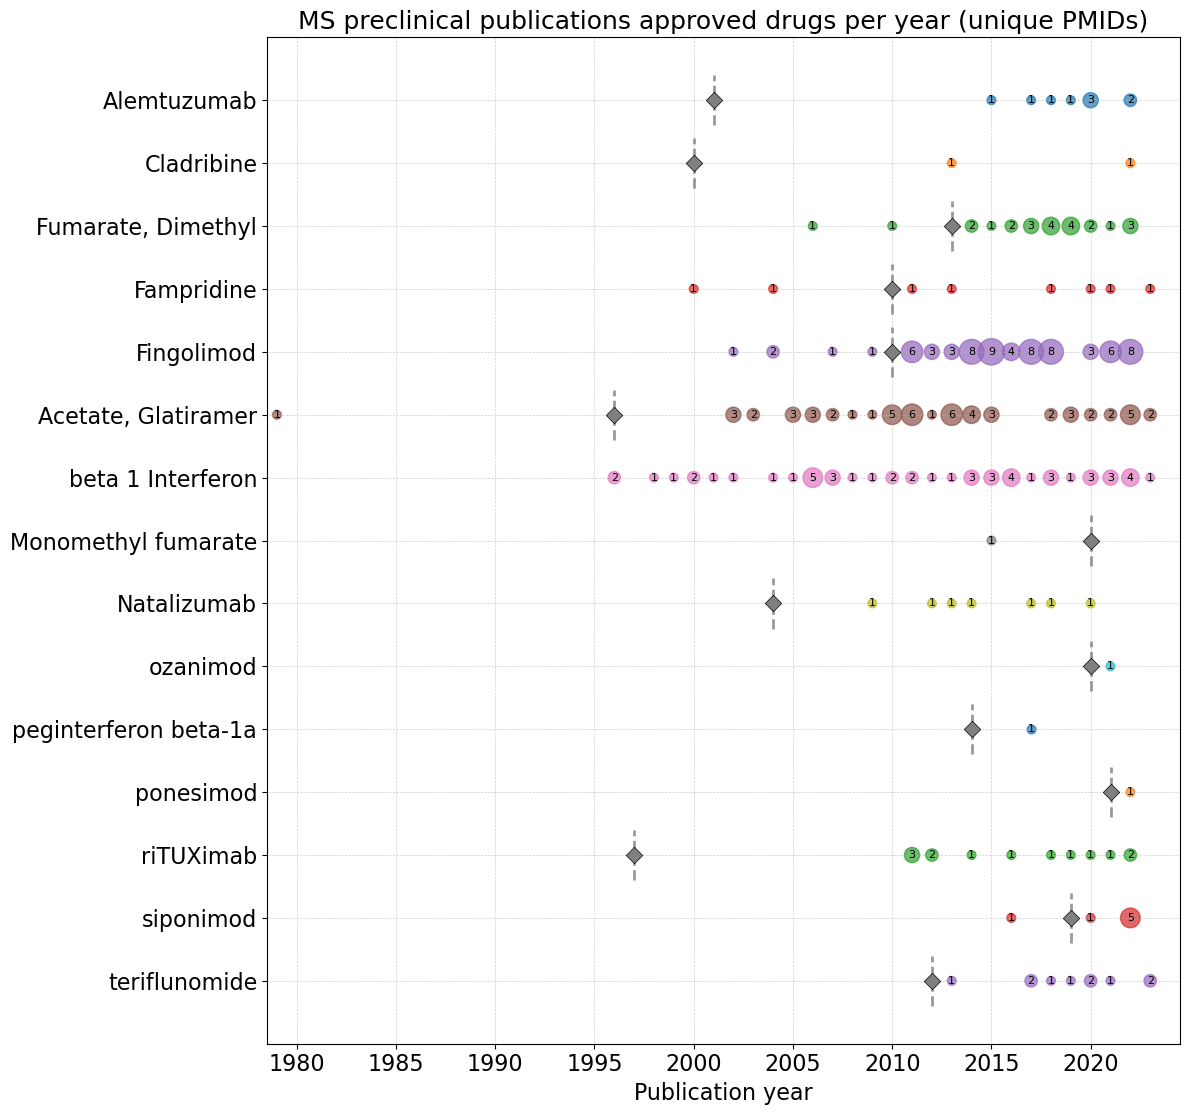

In [436]:
plot_drug_year_bubbles_from_wide(
    drug_years=drug_approval_years,
    wide_df=wide_approved,
    title="MS preclinical publications approved drugs per year (unique PMIDs)",
    output_file="outputs/drug_timeline.png",
    drugs_custom_order=approved_drugs_list,  # optional
    year_range=(1979, 2024),
    scale=40
)

In [447]:
all_drugs_timeline = pd.read_csv("../10_use_case_disease_focus/out/all_drugs_articles_timeline.csv")

In [448]:
all_drugs_timeline = format_wide_to_indexed(all_drugs_timeline)


Plotting 15 drugs
Saved plot to: outputs/drug_timeline.png


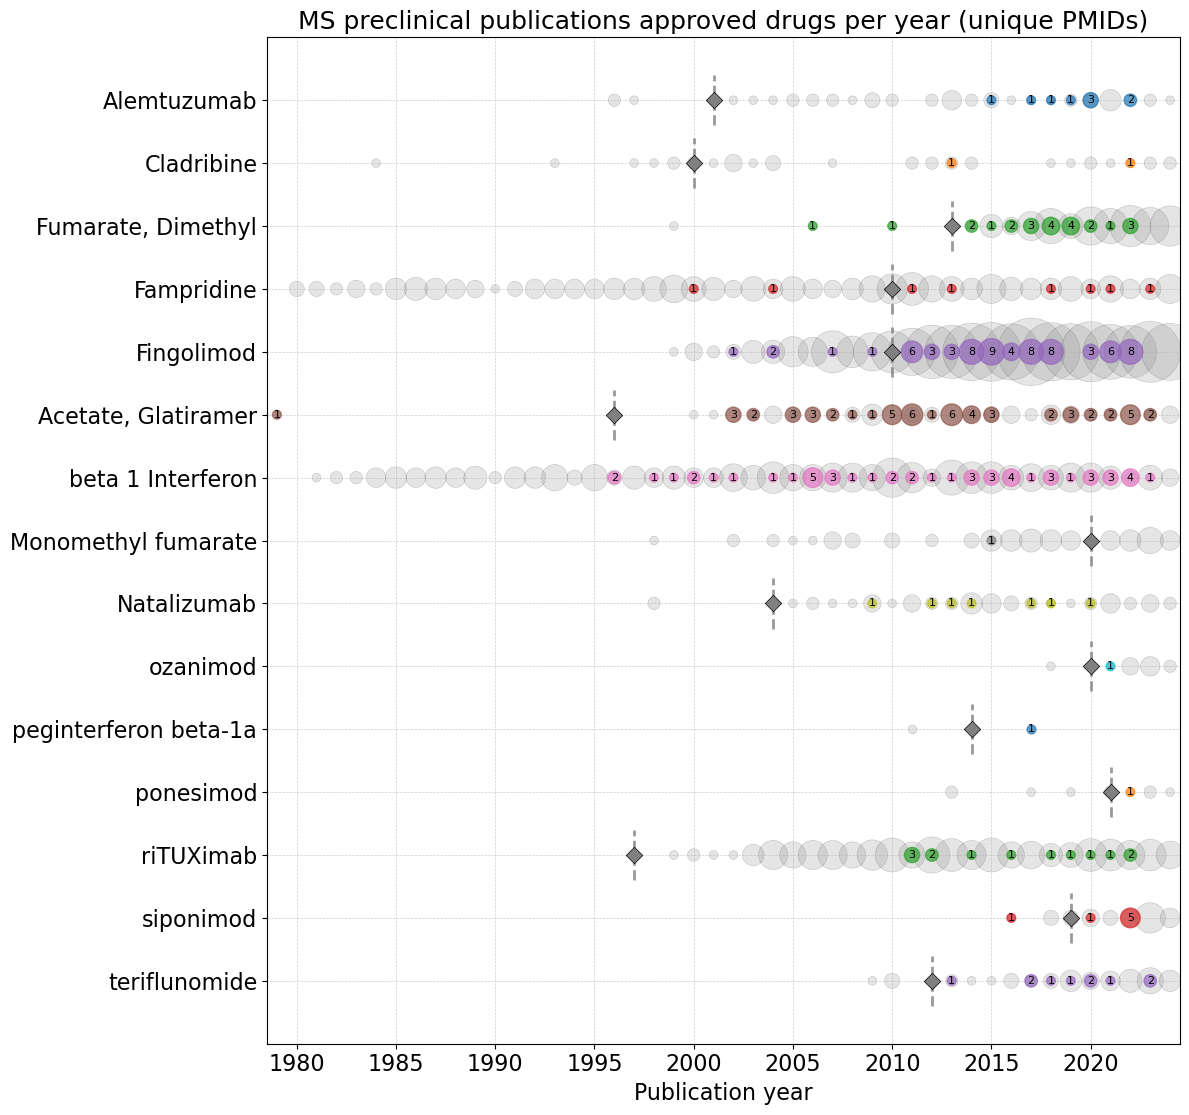

In [474]:
plot_drug_year_bubbles_from_wide(
    drug_years=drug_approval_years,
    wide_df=wide_approved,
    title="MS preclinical publications approved drugs per year (unique PMIDs)",
    extra_studies_df = all_drugs_timeline,
    output_file="outputs/drug_timeline.png",
    drugs_custom_order=approved_drugs_list,  # optional
    year_range=(1979, 2024),
    scale=40
)

In [442]:
all_drugs_timeline

,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,Total
drug_term_umls_norm_manual_clean,,,,,,,,,,,,,,,,,,,,,
Dexamethasone,29,26,31,24,32,32,44,45,49,45,...,215,184,207,212,198,226,228,168,190,5781
Acetylcysteine,1,4,4,4,6,11,19,18,14,17,...,194,193,213,210,226,206,204,188,176,4454
Doxorubicin,7,15,22,12,19,39,12,24,22,28,...,230,196,256,274,261,232,246,222,189,4378
NG-Nitroarginine Methyl Ester,0,0,0,0,0,0,0,0,0,0,...,91,79,79,83,85,62,57,37,34,4164
Sirolimus,0,0,0,0,1,0,0,0,0,0,...,209,205,241,259,274,278,244,216,214,3824
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
diazepinobenzimidazole compound,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,1
diazepinomicin,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
diazepinone derivatives,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1


In [444]:
def format_wide_to_indexed(
    df: pd.DataFrame,
    name_col: str = "drug_term_umls_norm_manual_clean",
    index_name: str = "unique_drug_target"
) -> pd.DataFrame:
    out = df.copy()

    # Convert year-like columns to ints (keep 'Total' as-is)
    year_like = [c for c in out.columns if c not in [name_col, "Total"]]
    col_map = {}
    for c in year_like:
        try:
            col_map[c] = int(c)
        except (ValueError, TypeError):
            pass  # ignore non-year extras
    out = out.rename(columns=col_map)

    # Set index to drug name
    out = out.set_index(name_col)
    out.index.name = index_name

    # Determine ordered year columns
    year_cols = sorted([c for c in out.columns if isinstance(c, int)])

    # Ensure numeric and integer dtype
    out[year_cols] = out[year_cols].apply(pd.to_numeric, errors="coerce").fillna(0).astype(int)

    # Add/position Total at the end
    if "Total" not in out.columns:
        out["Total"] = out[year_cols].sum(axis=1)
    else:
        out["Total"] = pd.to_numeric(out["Total"], errors="coerce").fillna(0).astype(int)

    out = out[year_cols + ["Total"]]

    # Name the columns axis as 'year'
    out.columns.name = "year"
    return out

year,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,Total
unique_drug_target,,,,,,,,,,,,,,,,,,,,,
Dexamethasone,29,26,31,24,32,32,44,45,49,45,...,215,184,207,212,198,226,228,168,190,5781
Acetylcysteine,1,4,4,4,6,11,19,18,14,17,...,194,193,213,210,226,206,204,188,176,4454
Doxorubicin,7,15,22,12,19,39,12,24,22,28,...,230,196,256,274,261,232,246,222,189,4378
NG-Nitroarginine Methyl Ester,0,0,0,0,0,0,0,0,0,0,...,91,79,79,83,85,62,57,37,34,4164
Sirolimus,0,0,0,0,1,0,0,0,0,0,...,209,205,241,259,274,278,244,216,214,3824
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
diazepinobenzimidazole compound,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,1
diazepinomicin,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
diazepinone derivatives,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1
